# IMPORTAR MATRIZ M

In [34]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
%matplotlib inline
import os

In [35]:
BASE = os.path.abspath("..")

SEED = 42

# Descargar y guardar la matriz de 146 muestras PCAWG
url = "https://github.com/8medom/SigFitTest/raw/main/real%20mutational%20catalogs/real_samples_WGS_PCAWG-146_input_profiles.dat"
M_df = pd.read_csv(url, sep='\t', comment='#', index_col=0)

# Guardar en data/
ruta = os.path.join(BASE, "data", "PCAWG_146_real.txt")
M_df.to_csv(ruta, sep='\t')

M = M_df.values.astype(float)
n_mut, n_tum = M.shape

print(f"M: {M.shape}")
print(f"Mutaciones por tumor — min: {M.sum(axis=0).min():,.0f}, max: {M.sum(axis=0).max():,.0f}, media: {M.sum(axis=0).mean():,.0f}")

M: (96, 146)
Mutaciones por tumor — min: 50,099, max: 2,432,617, media: 192,386


In [36]:
M_df

,Biliary-AdenoCA::SP99325,Bladder-TCC::SP1059,Bladder-TCC::SP96136,Breast-AdenoCA::SP117369,Breast-AdenoCA::SP2293,CNS-GBM::SP25494,ColoRect-AdenoCA::SP18310,ColoRect-AdenoCA::SP17172,ColoRect-AdenoCA::SP96133,ColoRect-AdenoCA::SP110242,...,Stomach-AdenoCA::SP84392,Stomach-AdenoCA::SP105018,Stomach-AdenoCA::SP84439,Stomach-AdenoCA::SP84922,Uterus-AdenoCA::SP90209,Uterus-AdenoCA::SP93540,Uterus-AdenoCA::SP93227,Uterus-AdenoCA::SP94933,Uterus-AdenoCA::SP92364,Uterus-AdenoCA::SP92659
Type,,,,,,,,,,,,,,,,,,,,,
A[C>A]A,542,883,268,92,61,190,239,321,674,554,...,473,1155,1171,276,291,197,648,528,457,692
A[C>A]C,595,486,206,48,31,211,261,280,368,423,...,375,1012,910,193,1028,222,5227,326,358,1040
A[C>A]G,72,146,53,9,7,25,25,32,64,55,...,32,134,115,25,40,27,168,59,62,119
A[C>A]T,895,605,155,40,39,221,462,491,495,723,...,426,1059,1664,183,6354,268,31709,303,386,3914
A[C>G]A,376,420,224,111,143,118,330,334,301,347,...,256,712,583,146,559,257,538,345,233,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T[T>C]T,6268,504,334,48,30,275,2006,2722,1450,1984,...,2703,588,10438,1111,2115,1594,5045,3175,3361,2166
T[T>G]A,812,207,183,25,13,67,42,170,133,77,...,101,559,685,299,65,24,129,159,194,4524
T[T>G]C,256,83,91,11,3,62,54,137,91,116,...,144,210,576,514,290,41,1250,203,248,1237


# HACER EL NMF CON SIPROFILEXTRACTOR

In [37]:
from SigProfilerExtractor import sigpro as sig
import os

output = os.path.join(BASE, "resultados", "extraccion_03")

if os.path.exists(os.path.join(output, "SBS96")):
    print("Extracción ya realizada, saltando.")
else:
    os.makedirs(output, exist_ok=True)
    sig.sigProfilerExtractor(
        input_type="matrix",
        output=output,
        input_data=ruta,
        reference_genome="GRCh37",
        minimum_signatures=1,
        maximum_signatures=12,
        nmf_replicates=50
    )

Extracción ya realizada, saltando.


# RESULTADOS DE NOVO

Matrices A y S

In [38]:
base_denovo = os.path.join(BASE, "resultados", "extraccion_03", "SBS96", "Suggested_Solution", "SBS96_De-Novo_Solution")

# Cargar S y A de novo
S_denovo_df = pd.read_csv(base_denovo + r"\Signatures\SBS96_De-Novo_Signatures.txt", sep="\t", index_col=0)
A_denovo_df = pd.read_csv(base_denovo + r"\Activities\SBS96_De-Novo_Activities_refit.txt", sep="\t", index_col=0)
S_sem_df    = pd.read_csv(base_denovo + r"\Signatures\SBS96_De-Novo_Signatures_SEM_Error.txt", sep="\t", index_col=0)

print("S de novo:", S_denovo_df.shape)
print("A de novo:", A_denovo_df.shape)
print("SEM de S: ", S_sem_df.shape)

S_denovo_df.head()

S de novo: (96, 8)
A de novo: (146, 8)
SEM de S:  (96, 8)


,SBS96A,SBS96B,SBS96C,SBS96D,SBS96E,SBS96F,SBS96G,SBS96H
MutationType,,,,,,,,
A[C>A]A,0.000761,0.001296,0.001375,0.049852,0.002221,0.003988,0.001499,0.000982
A[C>A]C,0.000368,0.002877,0.002719,0.027458,0.001724,0.002291,0.001560,0.000573
A[C>A]G,0.000039,0.000145,0.000140,0.011097,0.000015,0.000075,0.000145,0.000086
A[C>A]T,0.000436,0.011854,0.008519,0.032724,0.000010,0.002204,0.001798,0.000428
A[C>G]A,0.000439,0.000272,0.001559,0.014755,0.003216,0.001664,0.001329,0.002731


Firmas Asignadas

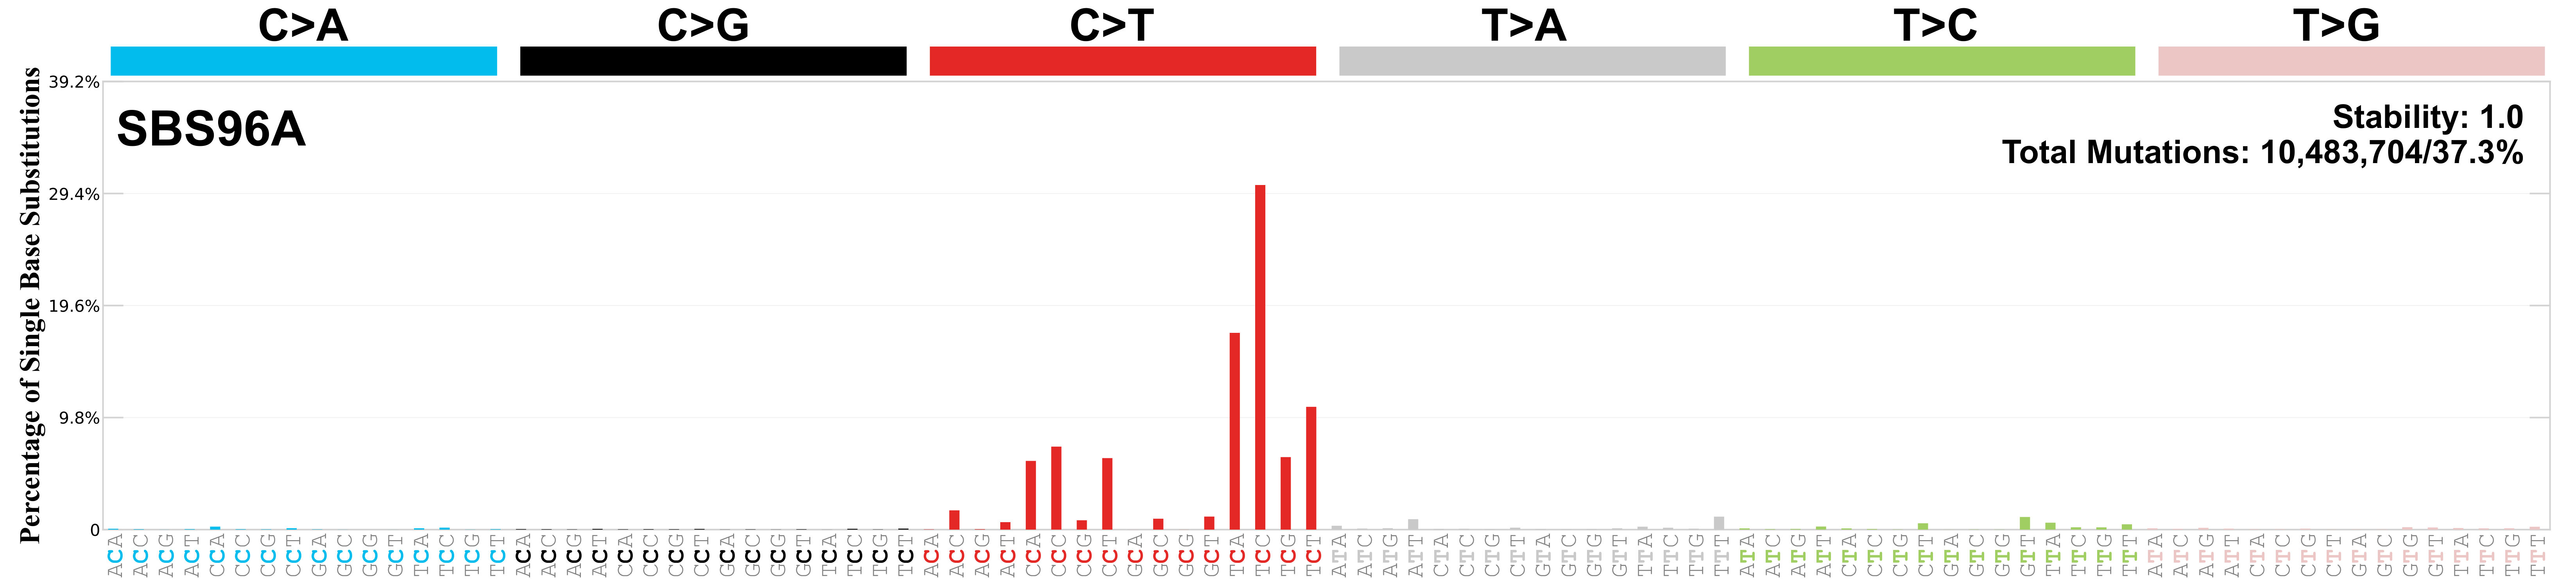

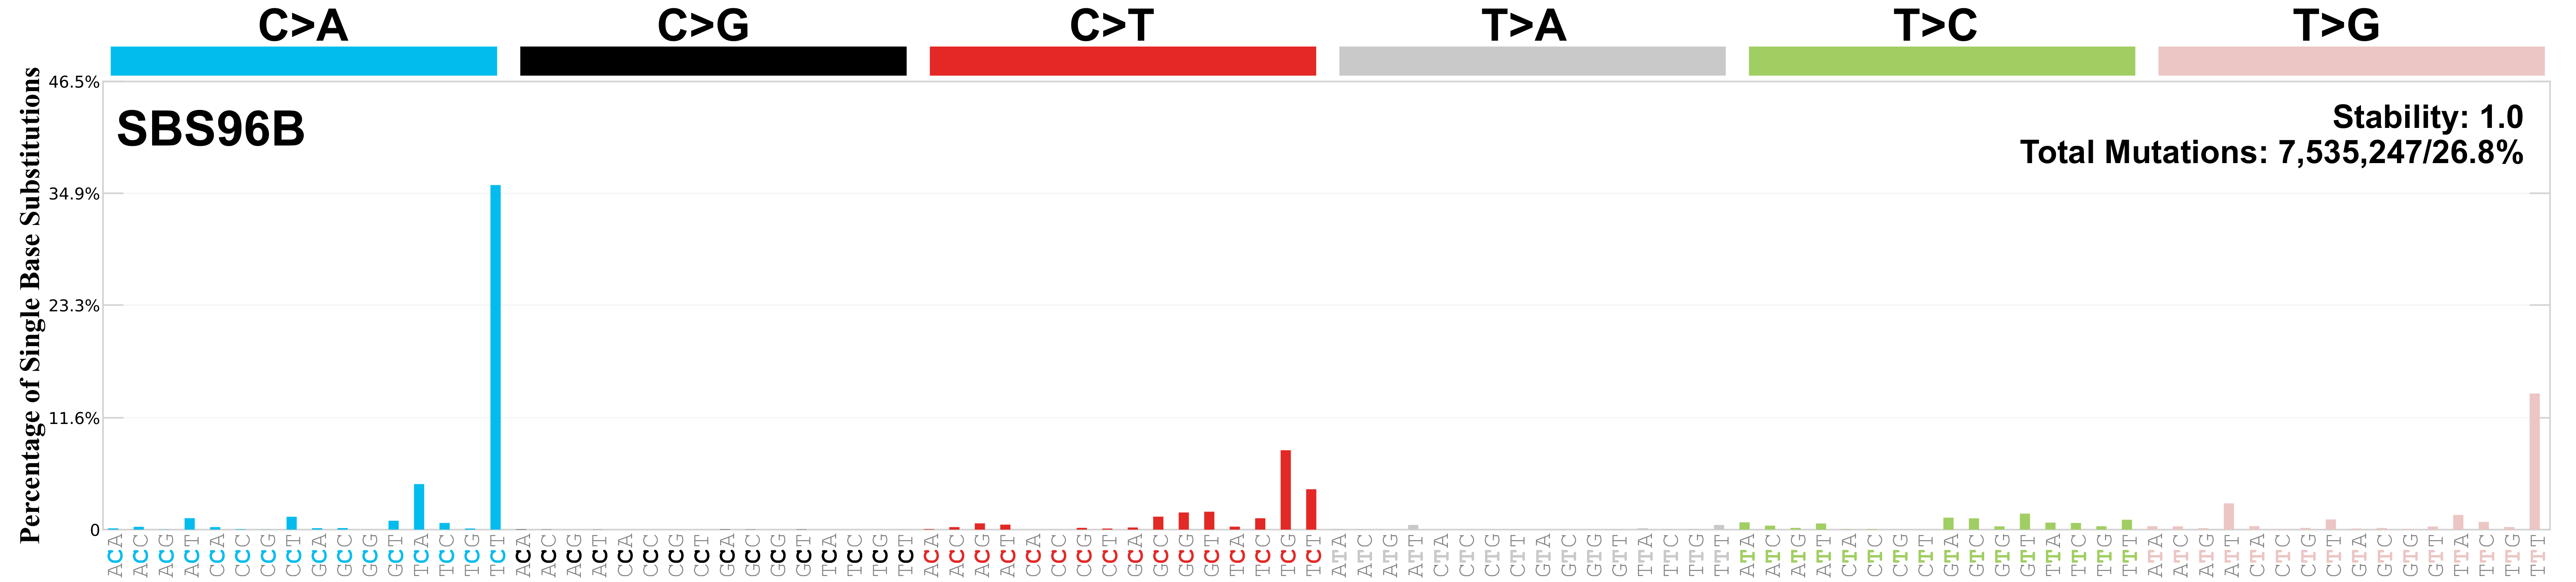

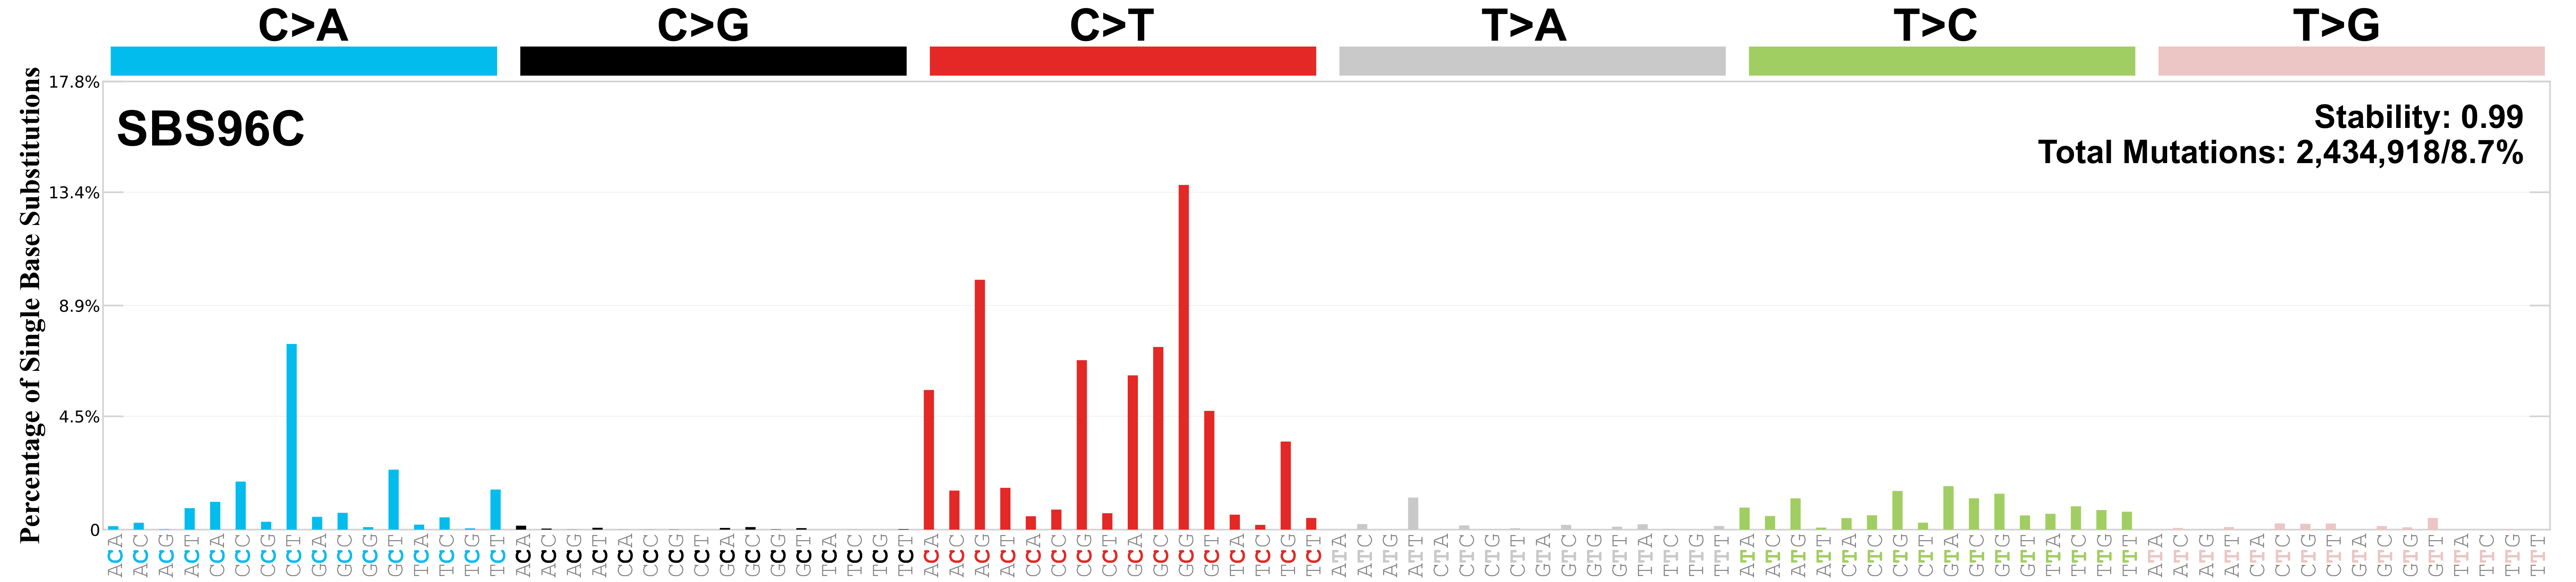

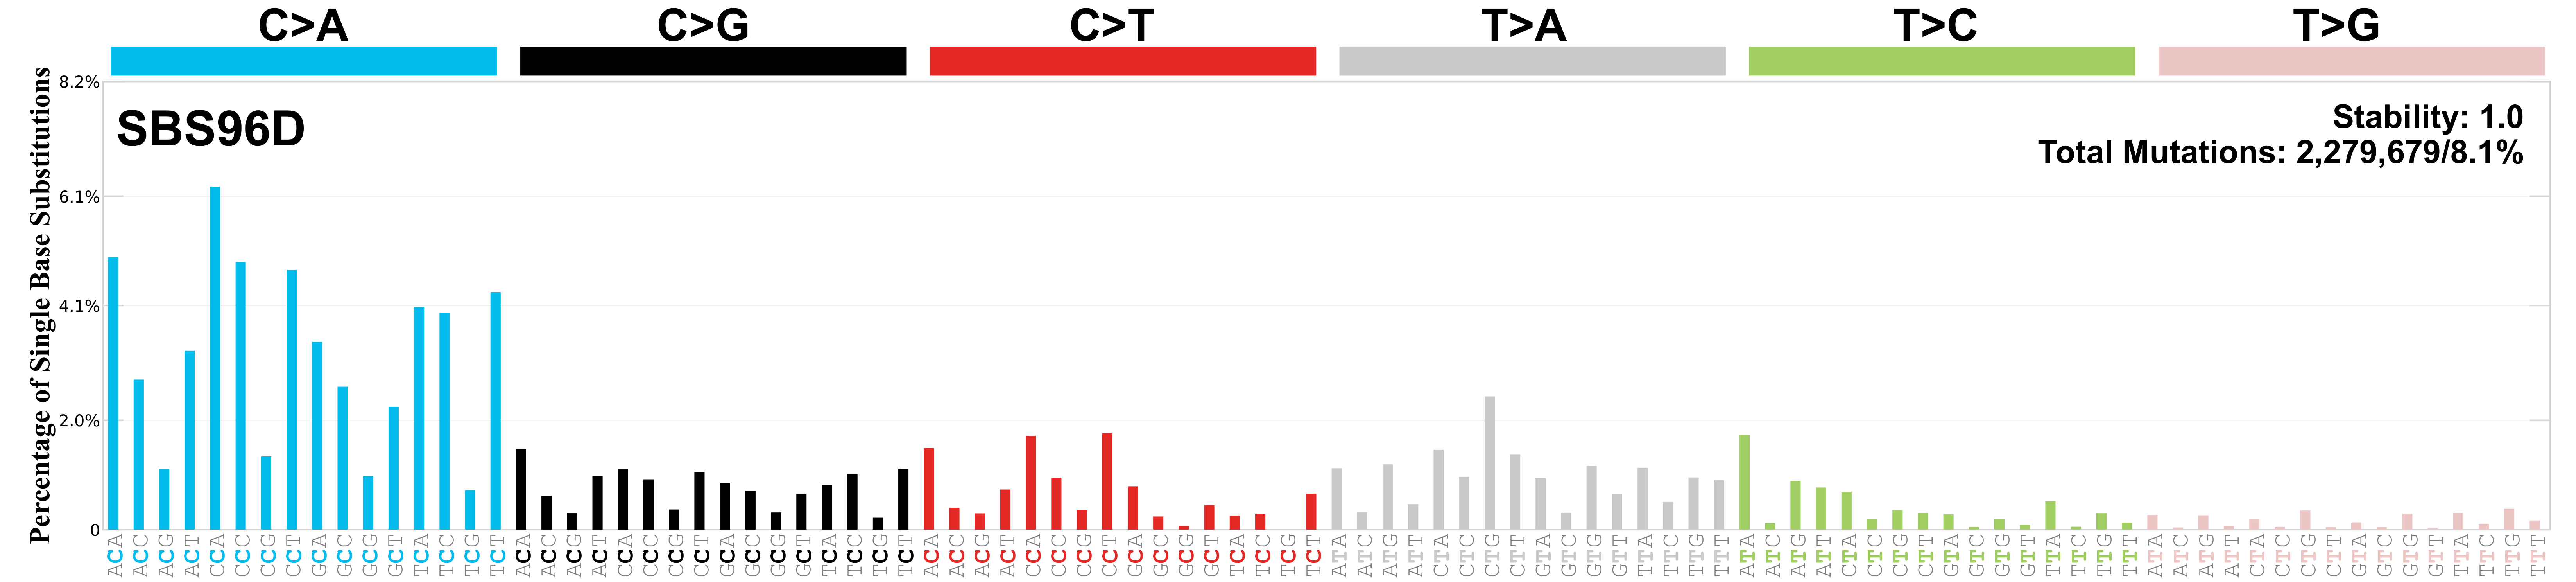

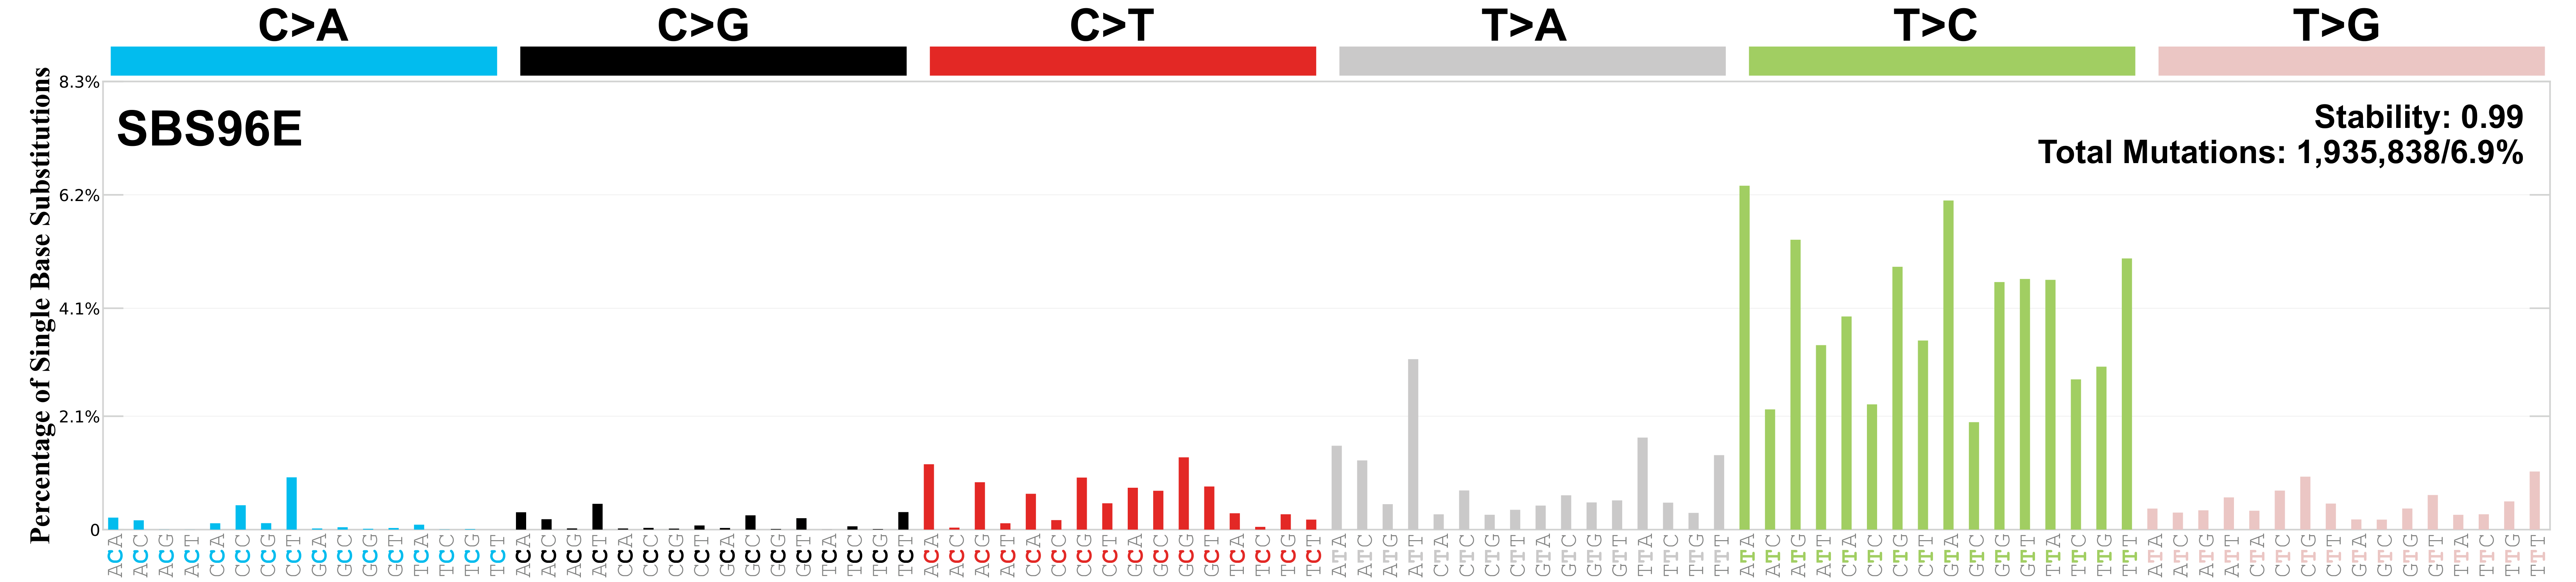

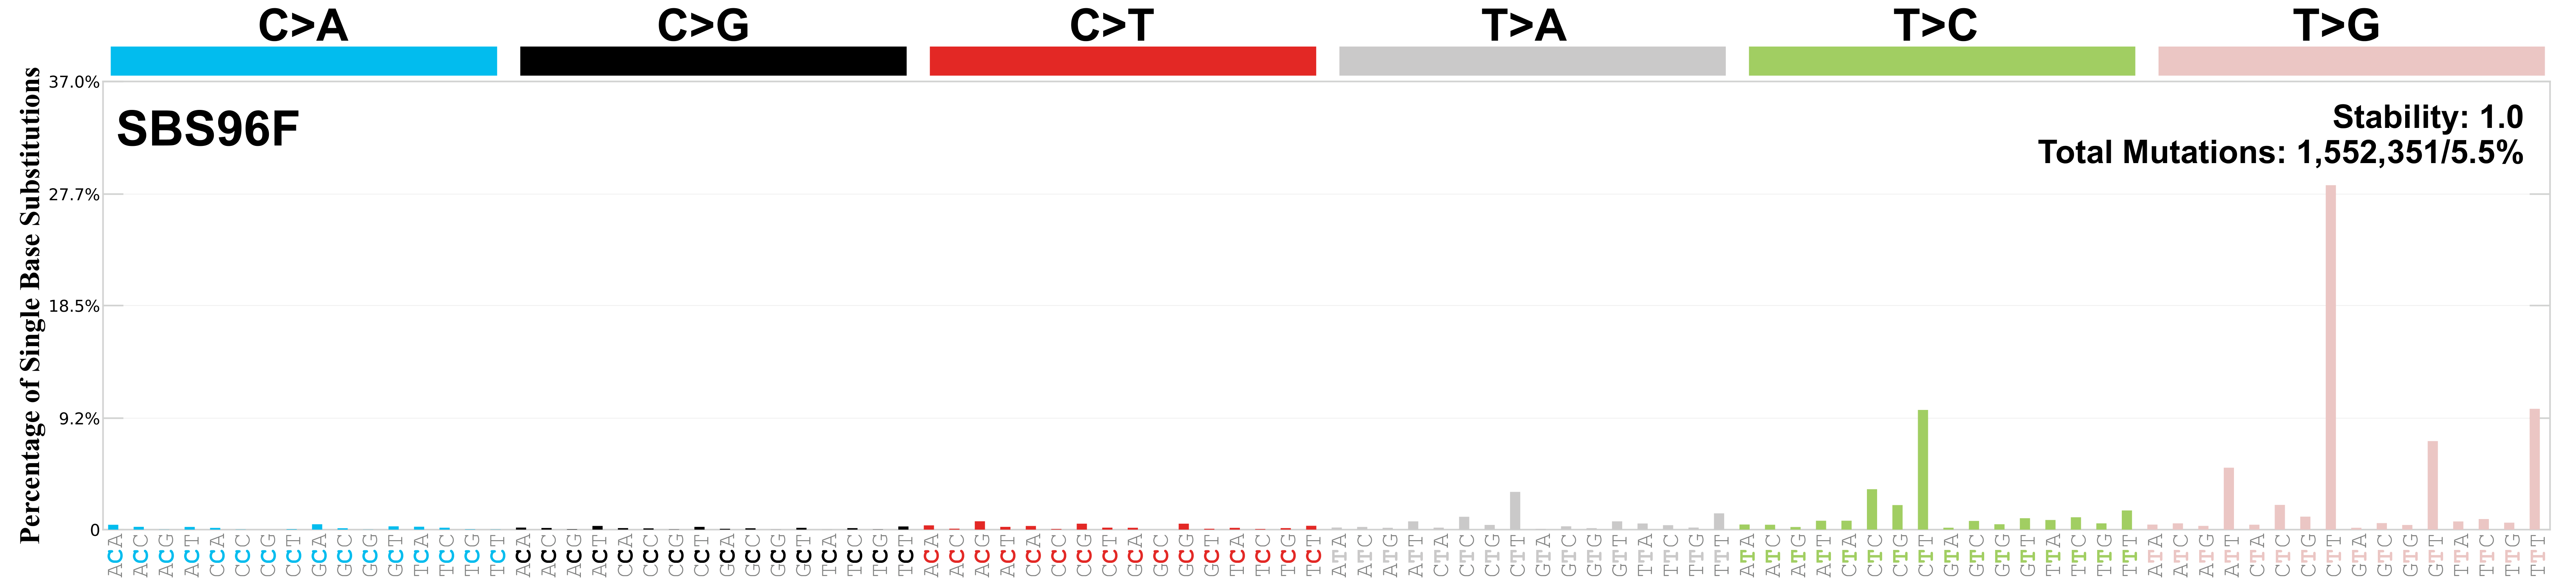

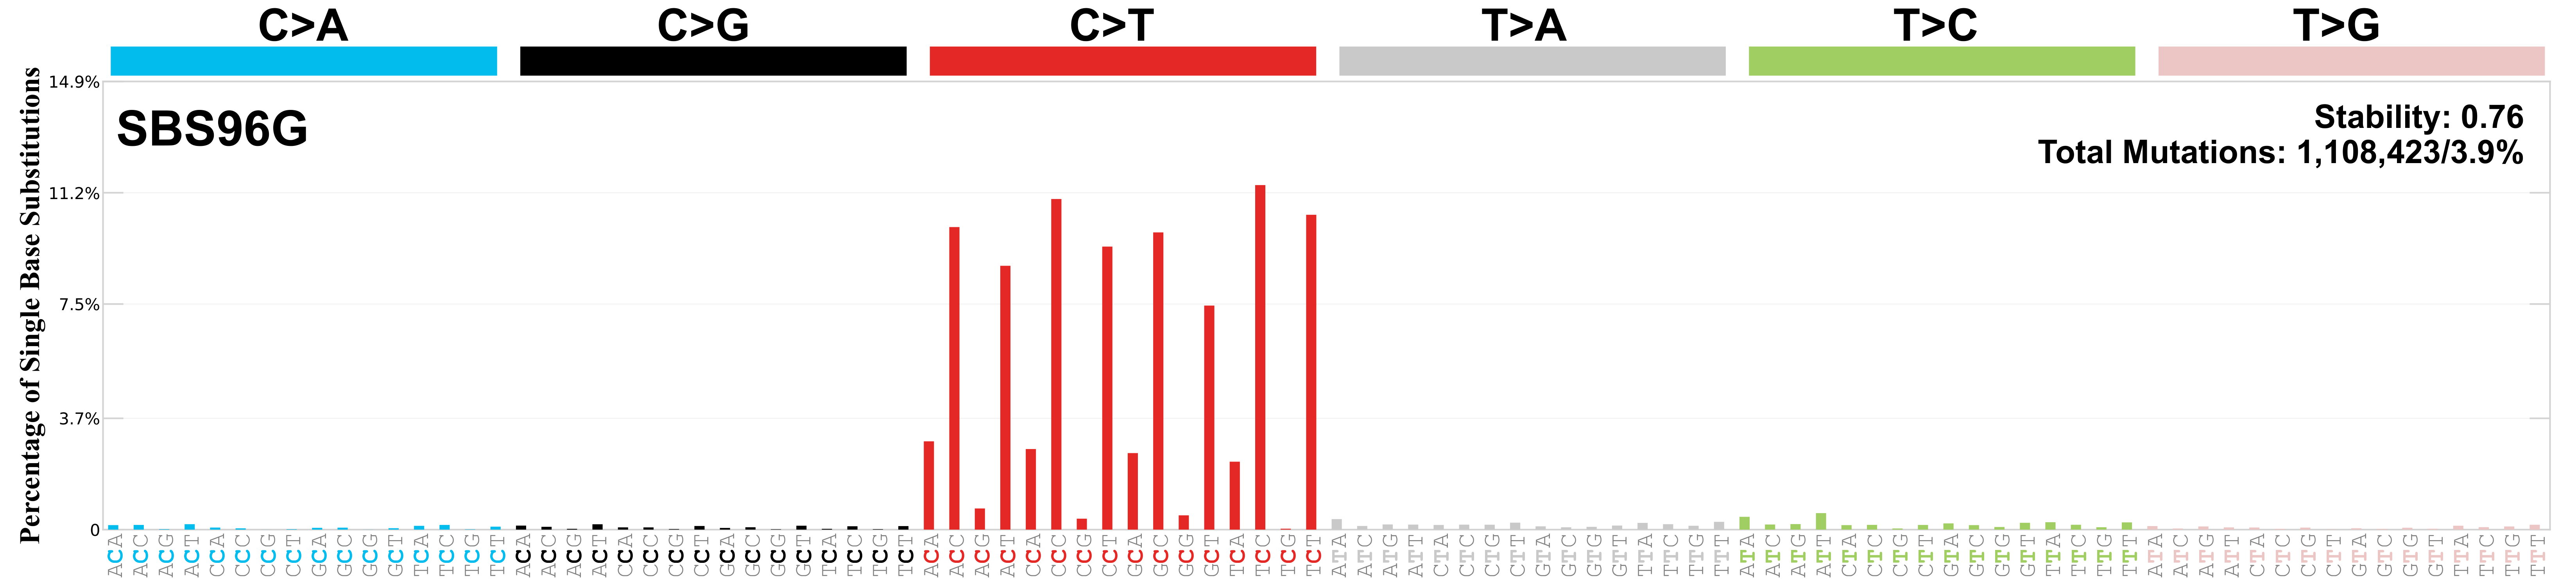

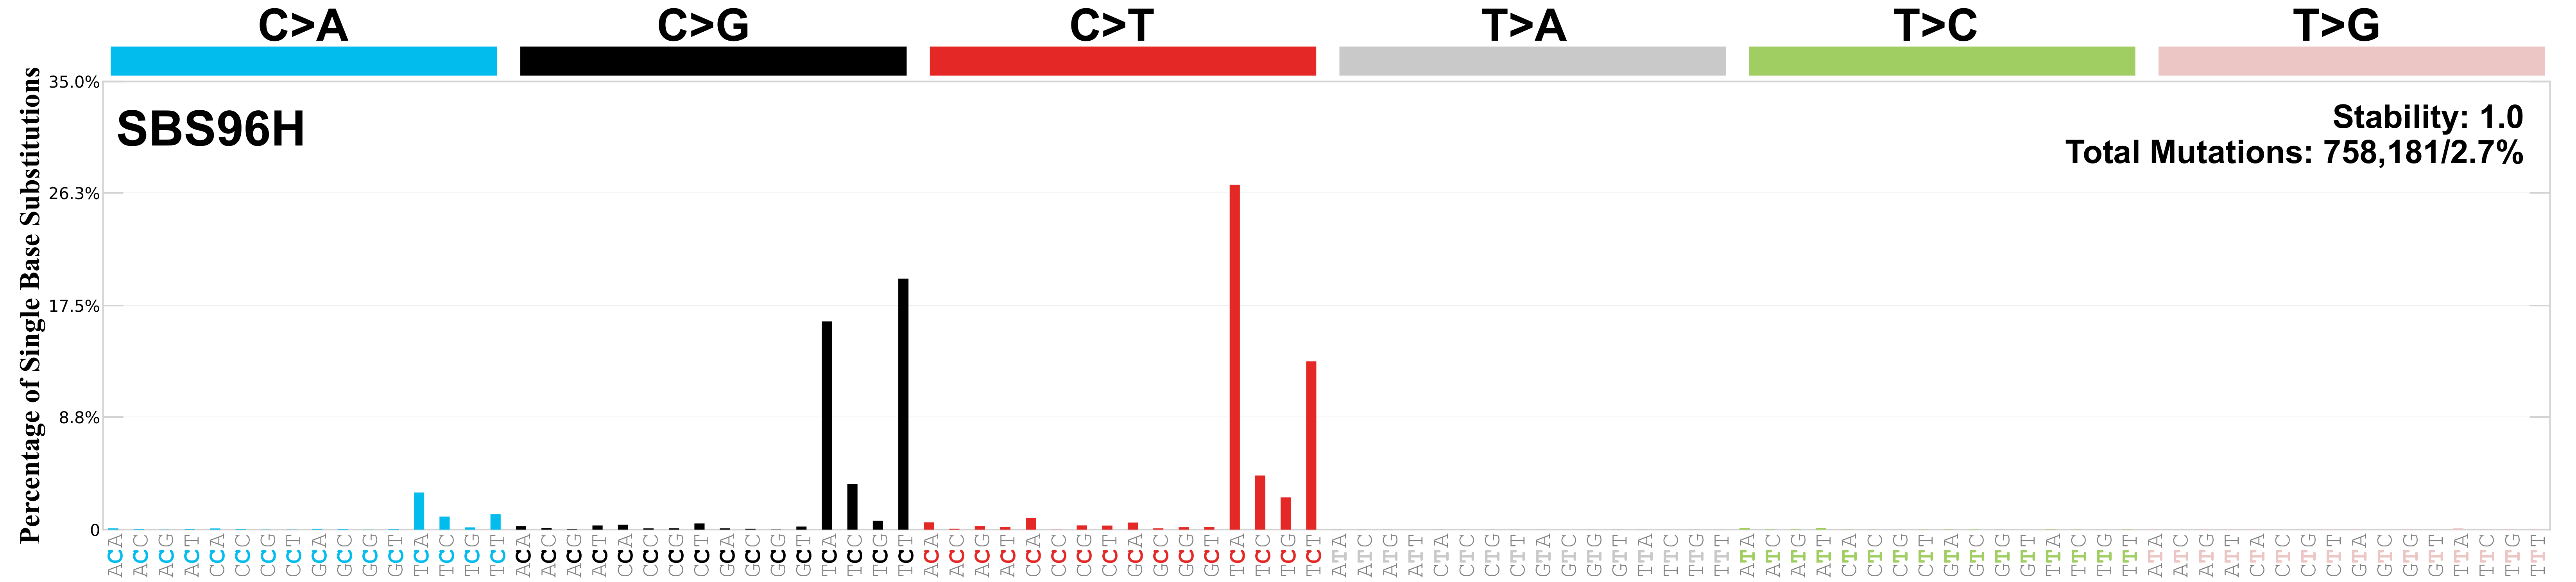

In [63]:
from IPython.display import Image
import fitz  # pip install pymupdf

# Convertir primera página del PDF a imagen
pdf_path = base_denovo + r"\Signatures\SBS_96_plots_SBS96_De-Novo.pdf"
doc = fitz.open(pdf_path)

for i, page in enumerate(doc):
    pix = page.get_pixmap(dpi=150)
    display(Image(data=pix.tobytes("png"), format='png'))

Explicación del número de firmas

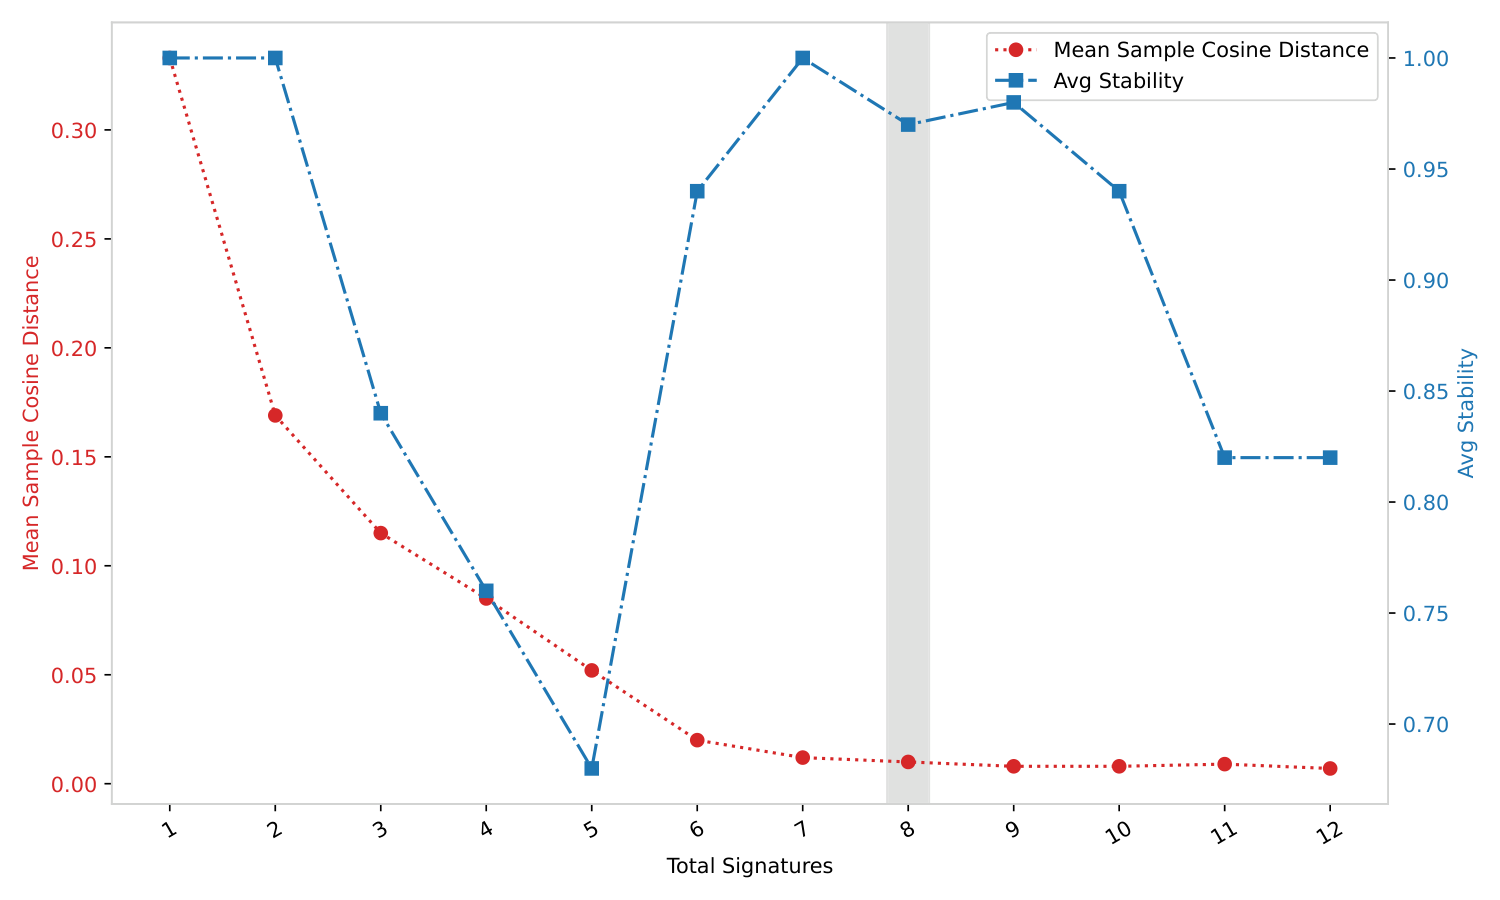

In [64]:
base_output = output  # = os.path.join(BASE, "resultados", "extraccion_03")

pdf_path = os.path.join(base_output, "SBS96", "SBS96_selection_plot.pdf")
doc = fitz.open(pdf_path)
for page in doc:
    pix = page.get_pixmap(dpi=150)
    display(Image(data=pix.tobytes("png"), format='png'))

Qué firmas se han detectado en cada tumor (146 tumores repartidos en 3 paginas)

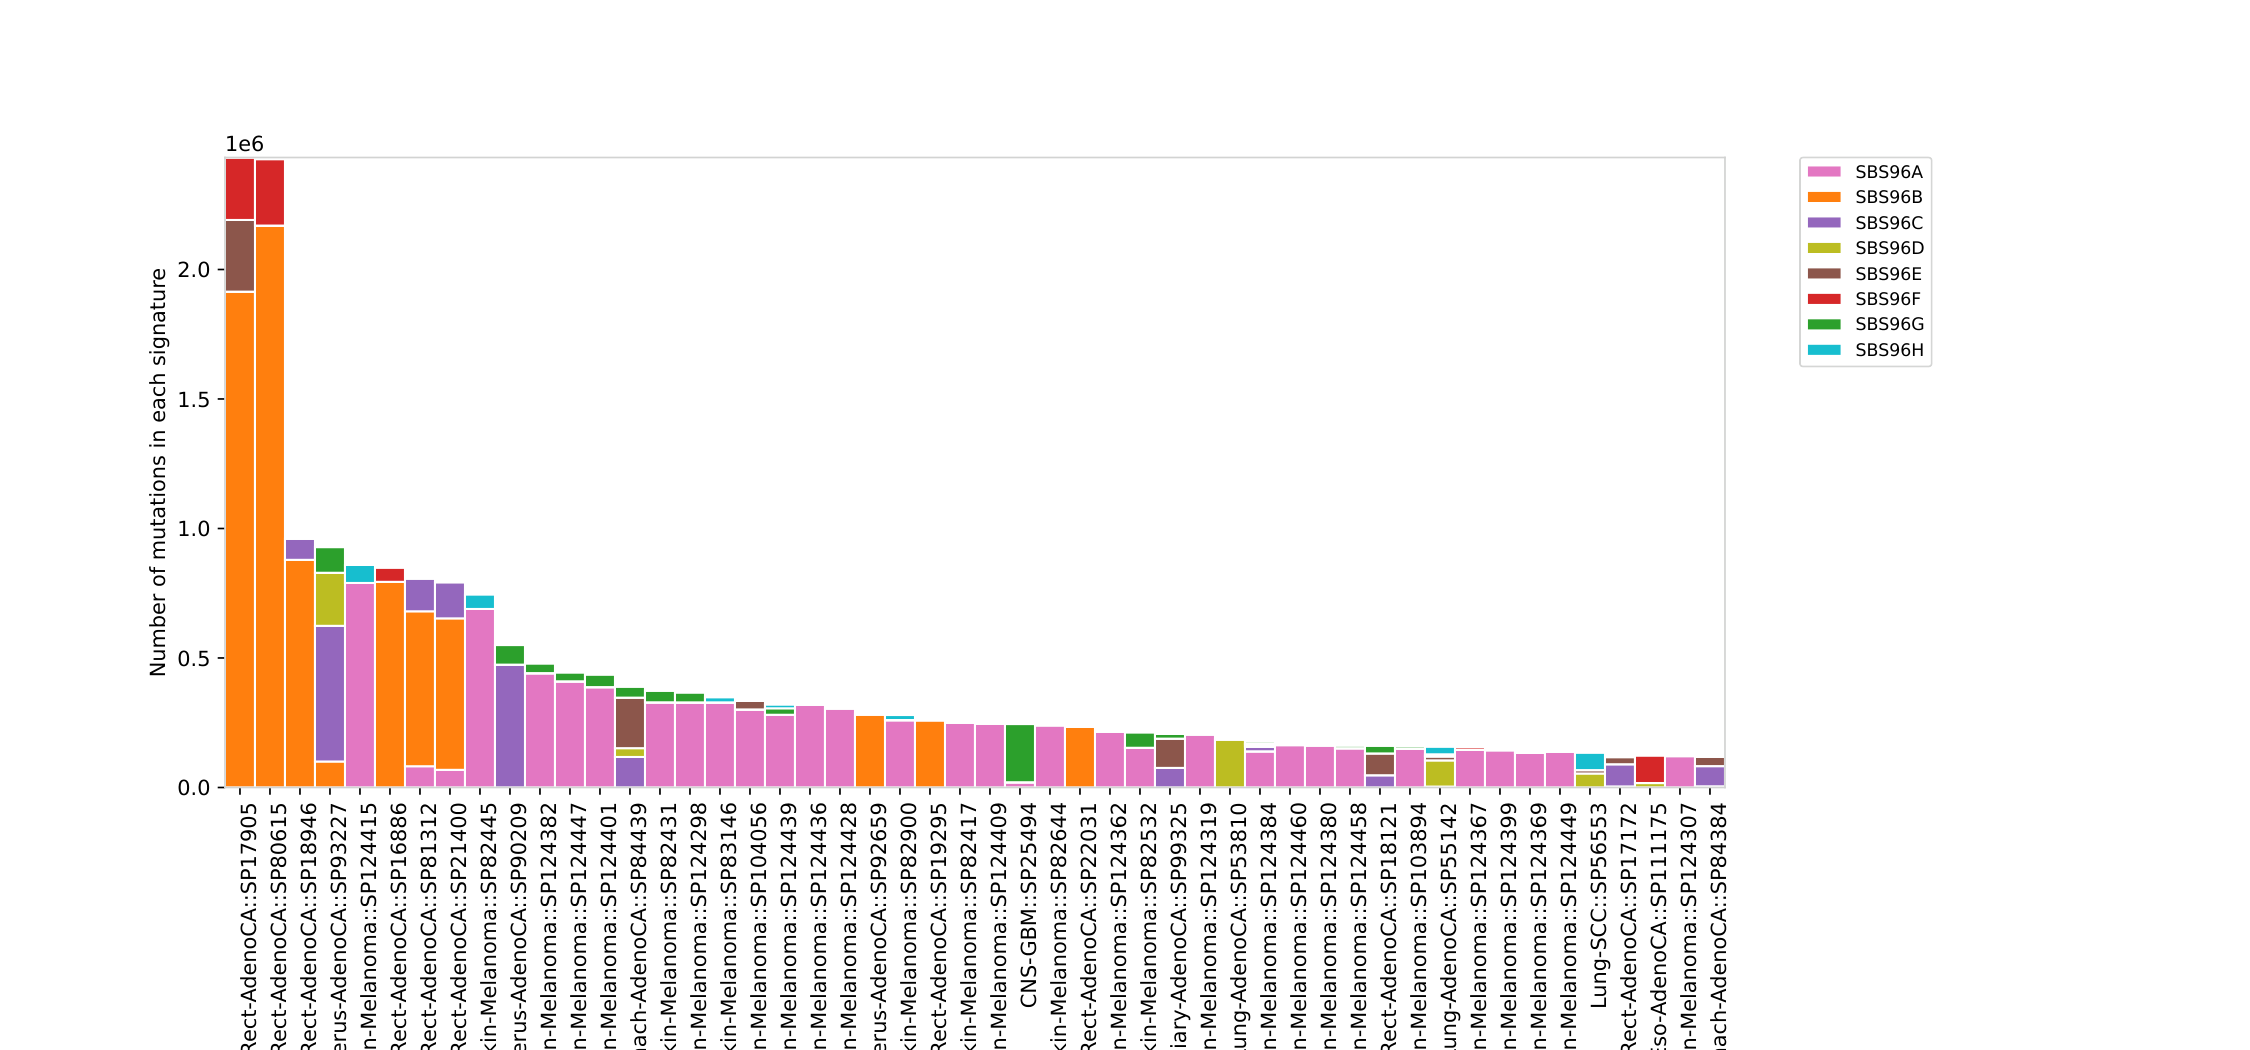

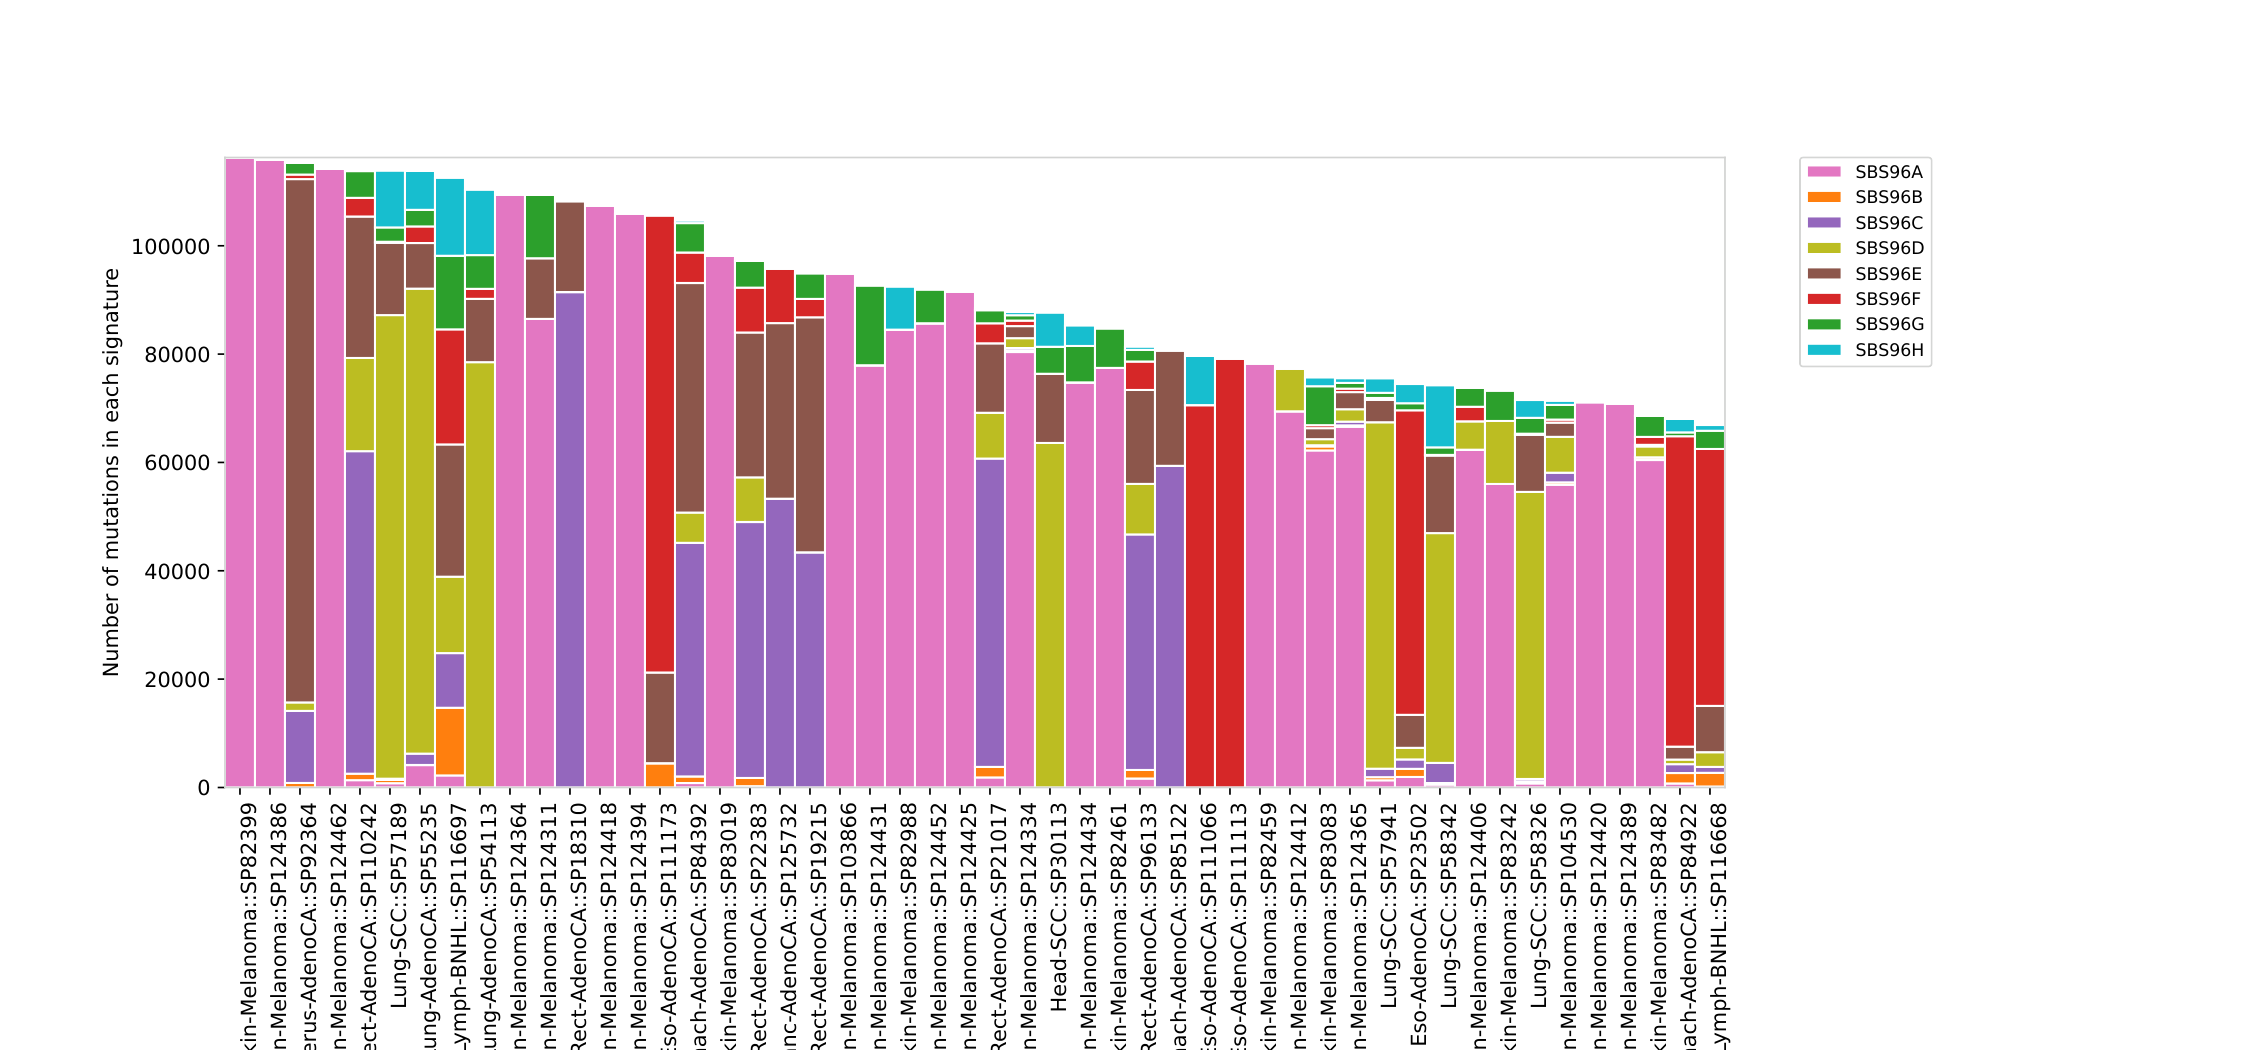

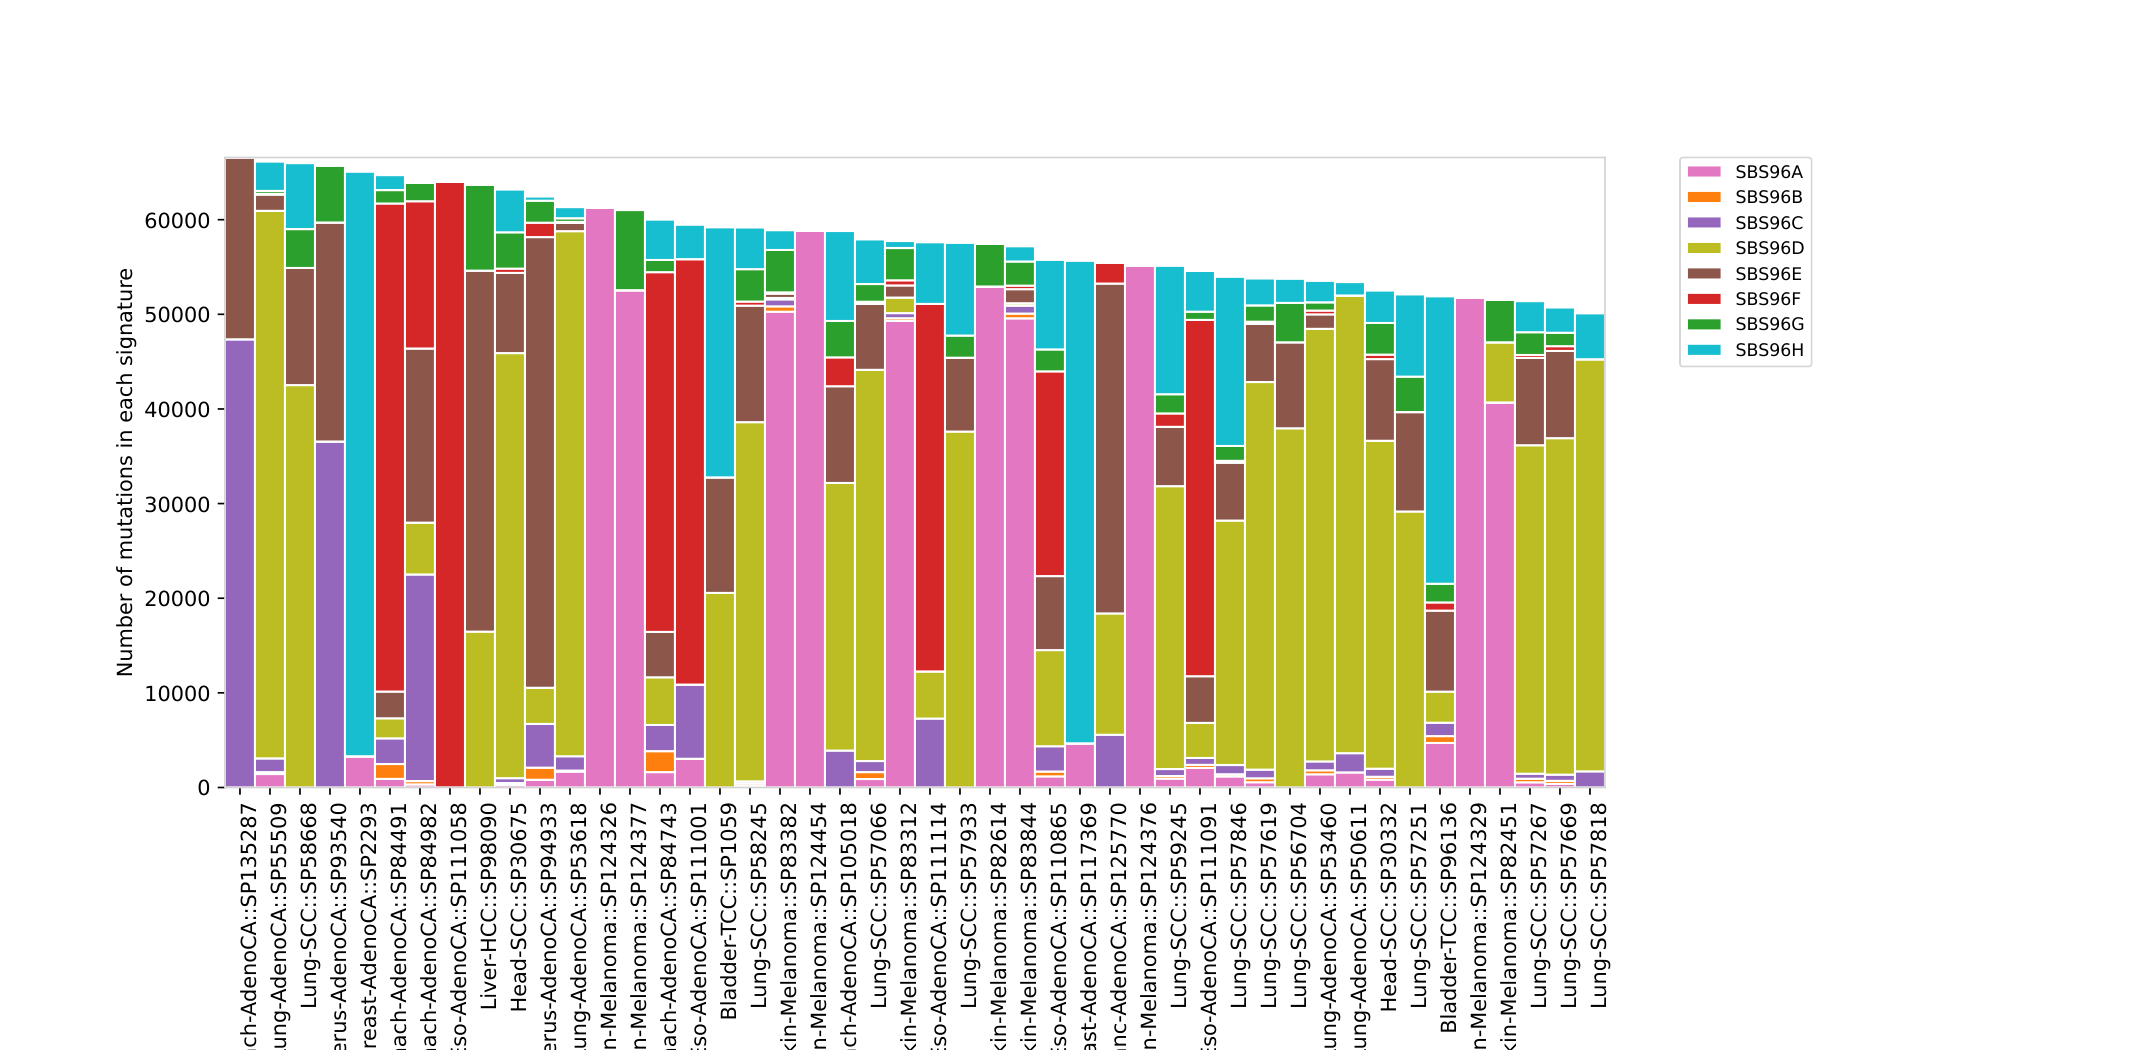

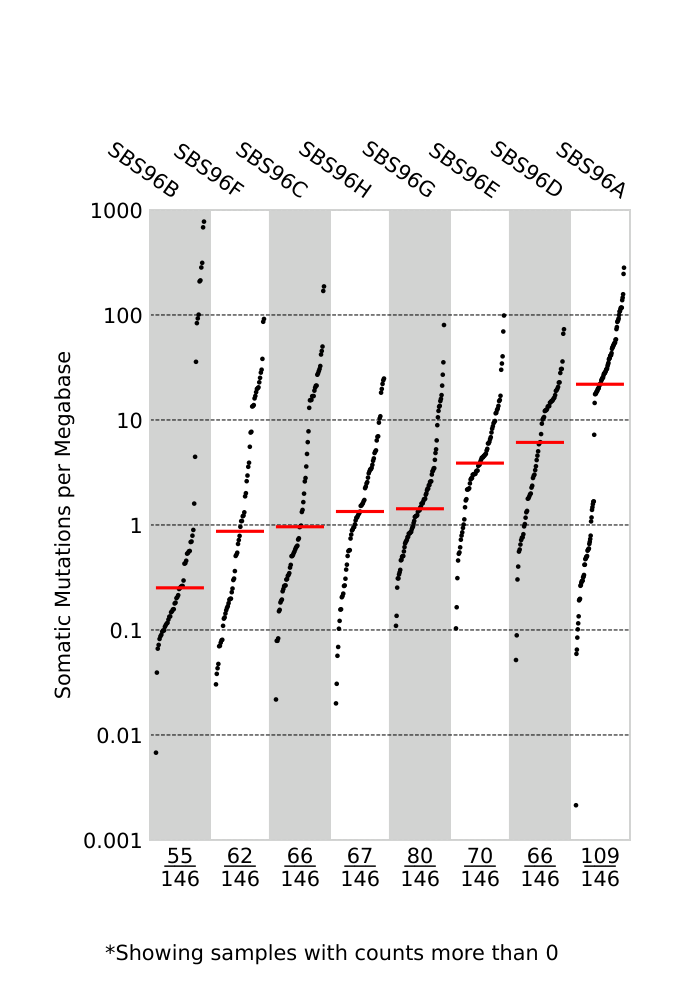

In [65]:
pdfs = [
    base_denovo + r"\Activities\SBS96_De-Novo_Activity_Plots_refit.pdf",
    base_denovo + r"\Activities\SBS96_De-Novo_TMB_plot_refit.pdf",
]

for pdf_path in pdfs:
    doc = fitz.open(pdf_path)
    for page in doc:
        pix = page.get_pixmap(dpi=150)
        display(Image(data=pix.tobytes("png"), format='png'))

# Correlación

## Matriz M

### Entre tumores (columnas)

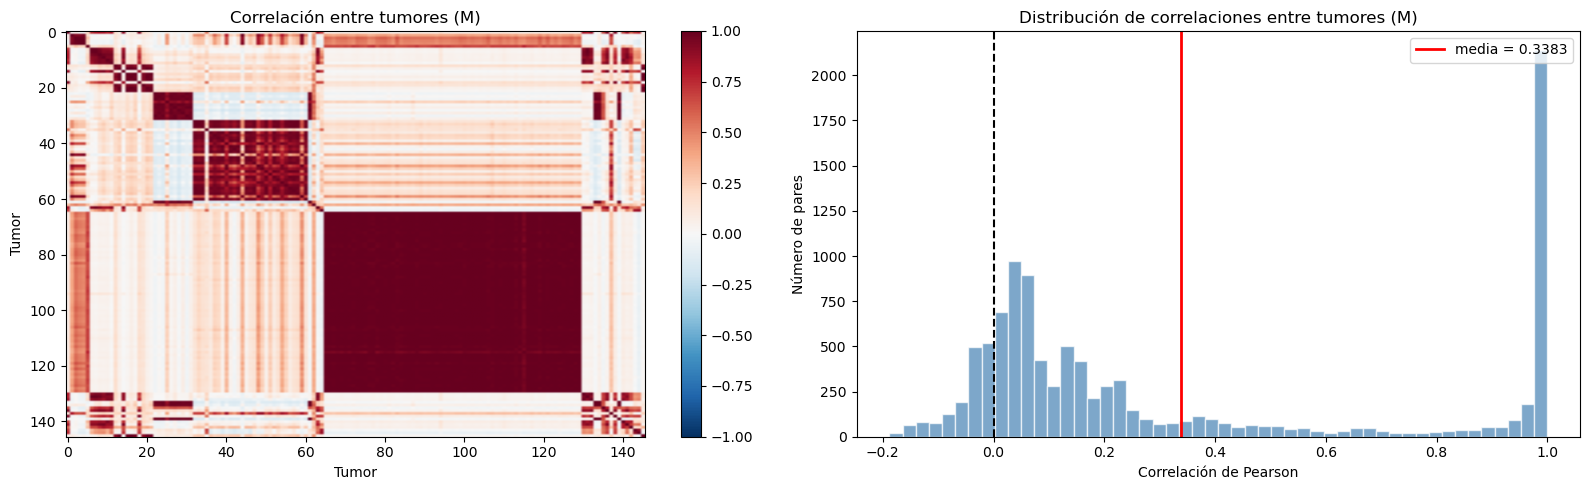

Correlación media: 0.3383
% pares con |corr| > 0.3: 35.2%
% pares con |corr| > 0.5: 29.1%


In [42]:
# Matriz de correlación de M (entre tumores/columnas)
corr_M = np.corrcoef(M.T)  # (146, 146)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(corr_M, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Correlación entre tumores (M)')
axes[0].set_xlabel('Tumor')
axes[0].set_ylabel('Tumor')
plt.colorbar(im, ax=axes[0])

corr_offdiag = corr_M[np.triu_indices(n_tum, k=1)]
axes[1].hist(corr_offdiag, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(corr_offdiag.mean(), color='red', linewidth=2,
                label=f'media = {corr_offdiag.mean():.4f}')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].set_ylabel('Número de pares')
axes[1].set_title('Distribución de correlaciones entre tumores (M)')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close('all')

print(f"Correlación media: {corr_offdiag.mean():.4f}")
print(f"% pares con |corr| > 0.3: {(np.abs(corr_offdiag) > 0.3).mean()*100:.1f}%")
print(f"% pares con |corr| > 0.5: {(np.abs(corr_offdiag) > 0.5).mean()*100:.1f}%")

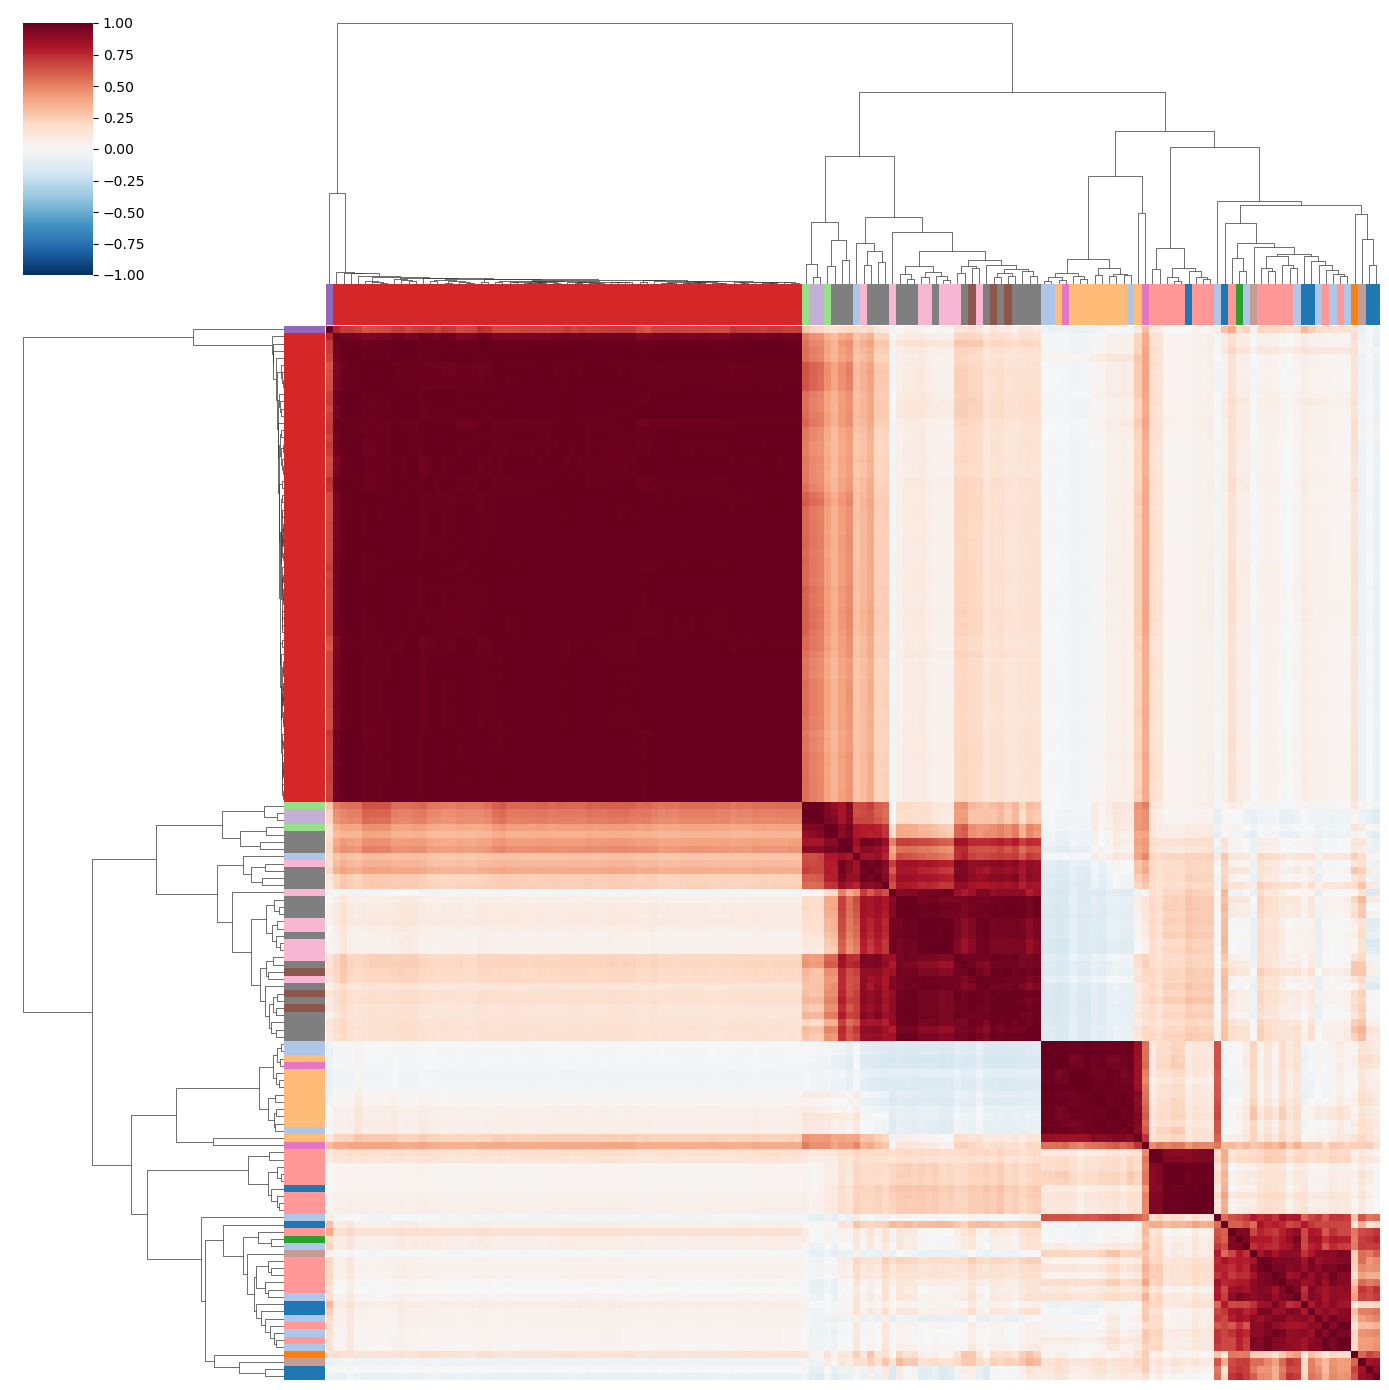

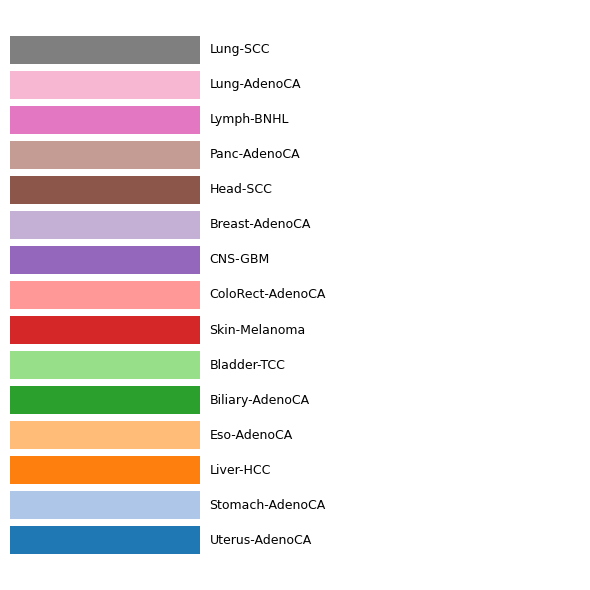

In [43]:
import seaborn as sns

# Extraer tipo de cáncer del nombre de cada muestra
cancer_types = [col.split("::")[0] for col in M_df.columns]

# Crear paleta de colores por tipo de cáncer
tipos_unicos = list(set(cancer_types))
palette = sns.color_palette("tab20", len(tipos_unicos))
color_map = dict(zip(tipos_unicos, palette))
col_colors = [color_map[t] for t in cancer_types]

# Clustermap
sns.clustermap(pd.DataFrame(corr_M, index=M_df.columns, columns=M_df.columns),
               cmap='RdBu_r', vmin=-1, vmax=1,
               col_colors=col_colors, row_colors=col_colors,
               figsize=(14, 14), xticklabels=False, yticklabels=False)
plt.show()
plt.close('all')

# Leyenda
fig, ax = plt.subplots(figsize=(6, len(tipos_unicos) * 0.4))
for i, (tipo, color) in enumerate(color_map.items()):
    ax.barh(i, 1, color=color)
    ax.text(1.05, i, tipo, va='center', fontsize=9)
ax.set_xlim(0, 3)
ax.axis('off')
plt.tight_layout()
plt.show()

### Entre tipos de mutacion (filas)

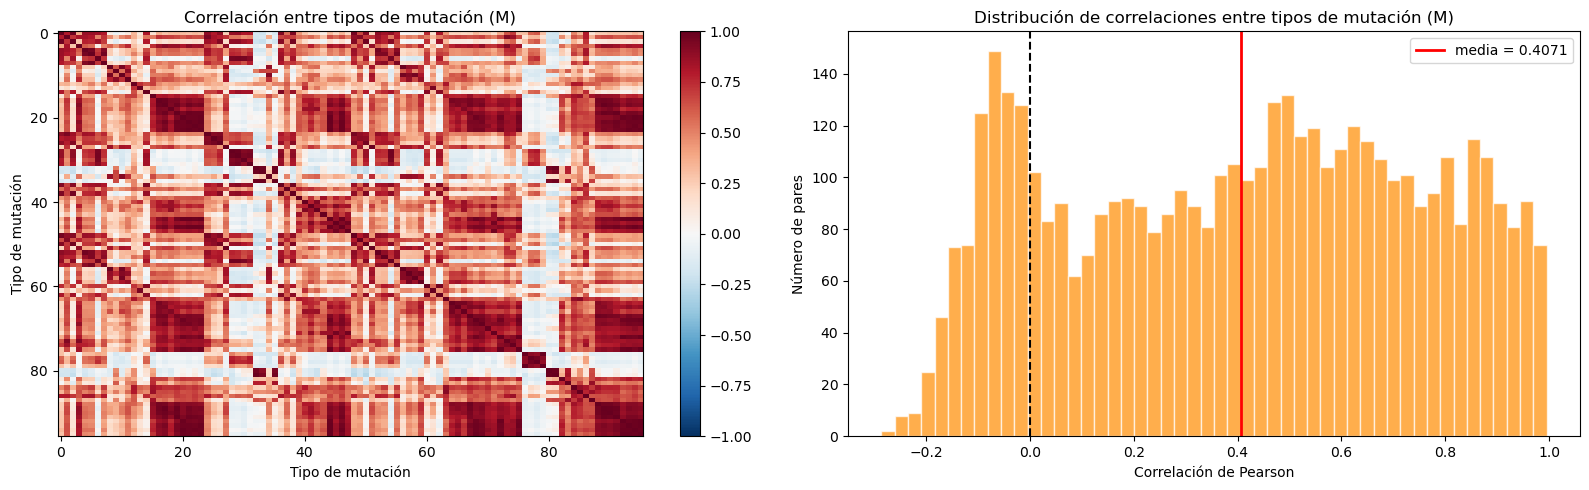

Correlación media: 0.4071
% pares con |corr| > 0.3: 60.9%
% pares con |corr| > 0.5: 43.3%


In [44]:
# Matriz de correlación de M (entre tipos de mutación/filas)
corr_M_filas = np.corrcoef(M)  # (96, 96)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(corr_M_filas, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Correlación entre tipos de mutación (M)')
axes[0].set_xlabel('Tipo de mutación')
axes[0].set_ylabel('Tipo de mutación')
plt.colorbar(im, ax=axes[0])

corr_offdiag_filas = corr_M_filas[np.triu_indices(n_mut, k=1)]
axes[1].hist(corr_offdiag_filas, bins=50, color='darkorange', alpha=0.7, edgecolor='white')
axes[1].axvline(corr_offdiag_filas.mean(), color='red', linewidth=2,
                label=f'media = {corr_offdiag_filas.mean():.4f}')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].set_ylabel('Número de pares')
axes[1].set_title('Distribución de correlaciones entre tipos de mutación (M)')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close('all')

print(f"Correlación media: {corr_offdiag_filas.mean():.4f}")
print(f"% pares con |corr| > 0.3: {(np.abs(corr_offdiag_filas) > 0.3).mean()*100:.1f}%")
print(f"% pares con |corr| > 0.5: {(np.abs(corr_offdiag_filas) > 0.5).mean()*100:.1f}%")

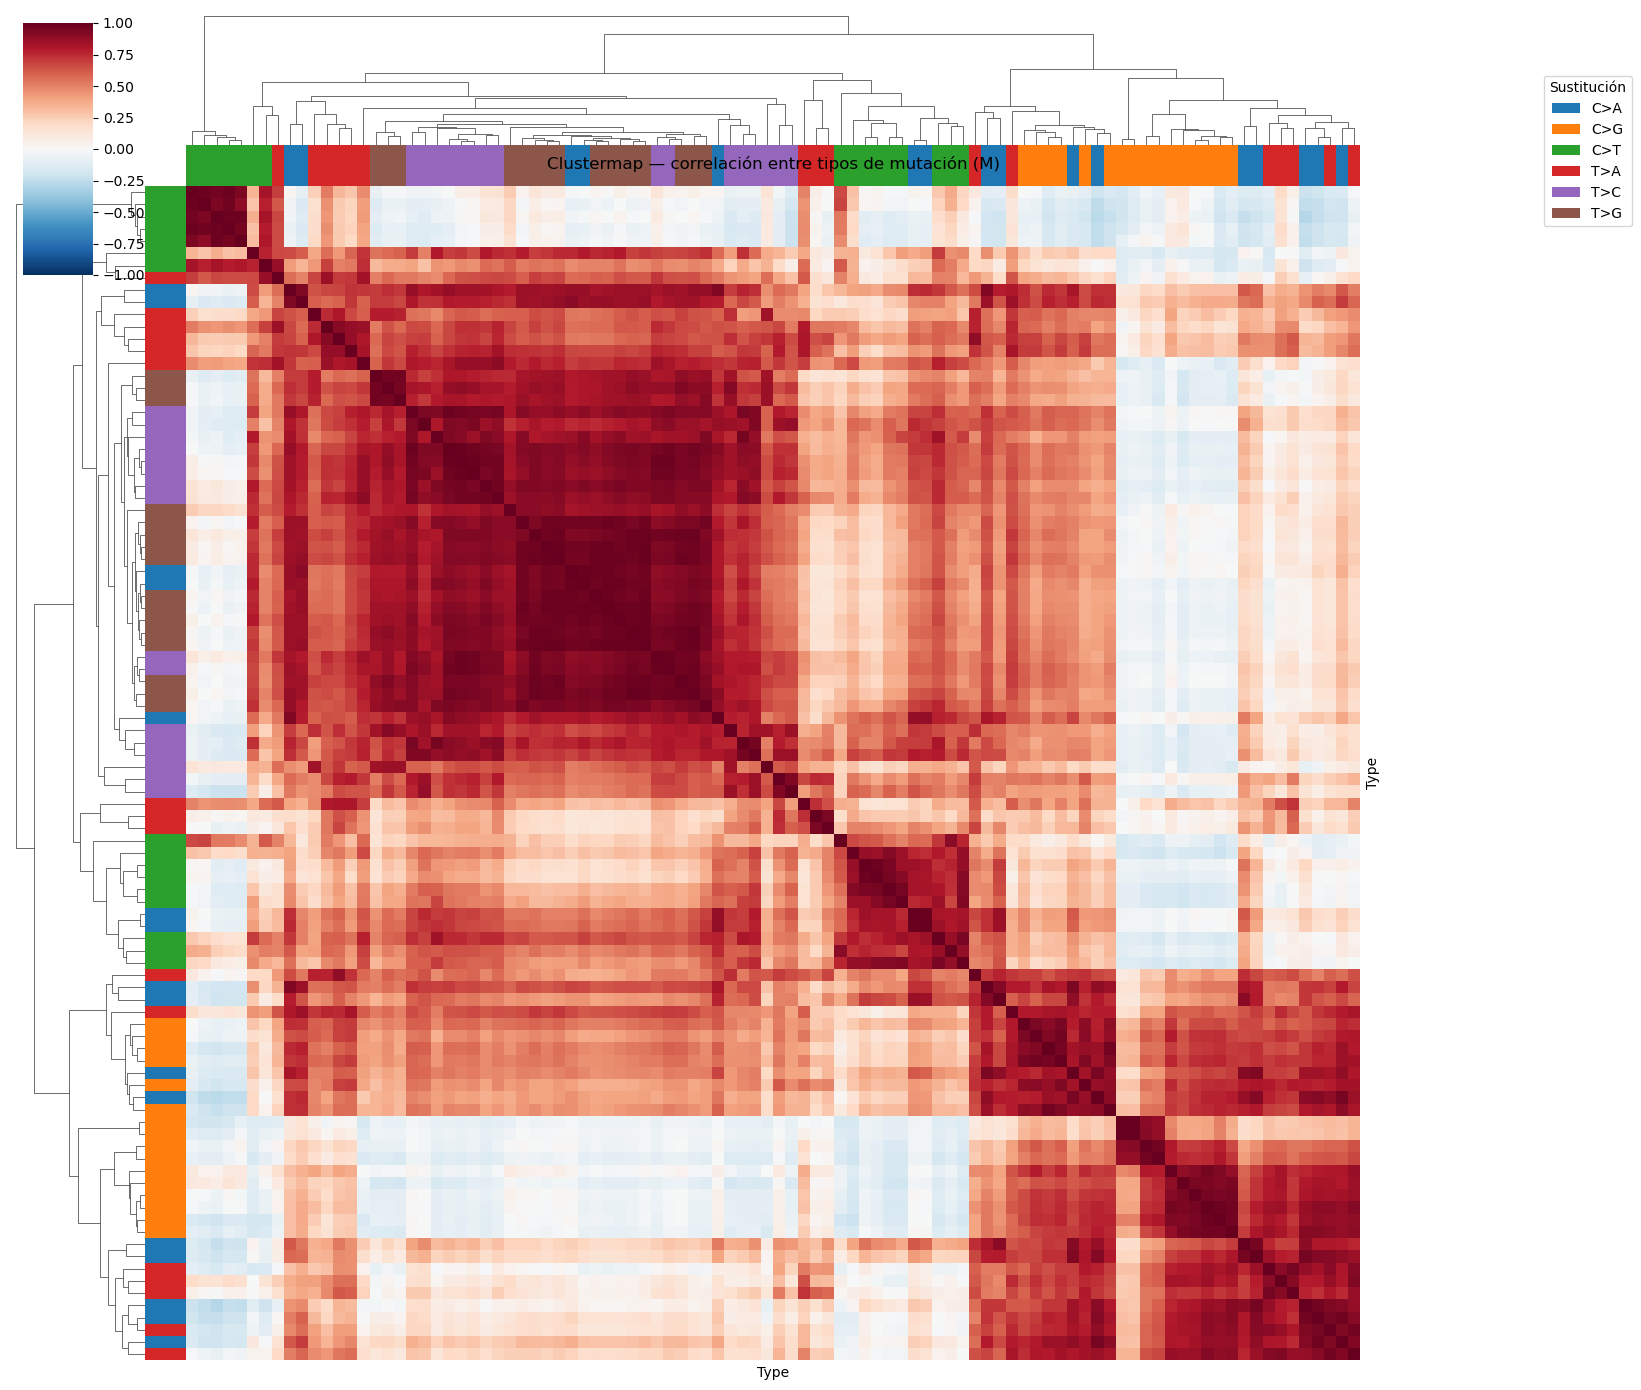

In [45]:
import seaborn as sns

# Extraer el tipo de sustitución del índice (formato "A[C>A]A")
sust_types = [idx.split('[')[1].split(']')[0] for idx in M_df.index]

tipos_sust = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
palette_sust = sns.color_palette("tab10", 6)
color_map_sust = dict(zip(tipos_sust, palette_sust))
row_colors_sust = [color_map_sust[t] for t in sust_types]

g = sns.clustermap(
    pd.DataFrame(corr_M_filas, index=M_df.index, columns=M_df.index),
    cmap='RdBu_r', vmin=-1, vmax=1,
    row_colors=row_colors_sust,
    col_colors=row_colors_sust,
    figsize=(14, 14),
    xticklabels=False, yticklabels=False,
    dendrogram_ratio=0.1,
)
g.ax_heatmap.set_title('Clustermap — correlación entre tipos de mutación (M)', pad=12)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map_sust[t], label=t) for t in tipos_sust]
g.ax_heatmap.legend(handles=legend_elements, loc='upper left',
                    bbox_to_anchor=(1.15, 1.1), title='Sustitución')
plt.show()
plt.close('all')

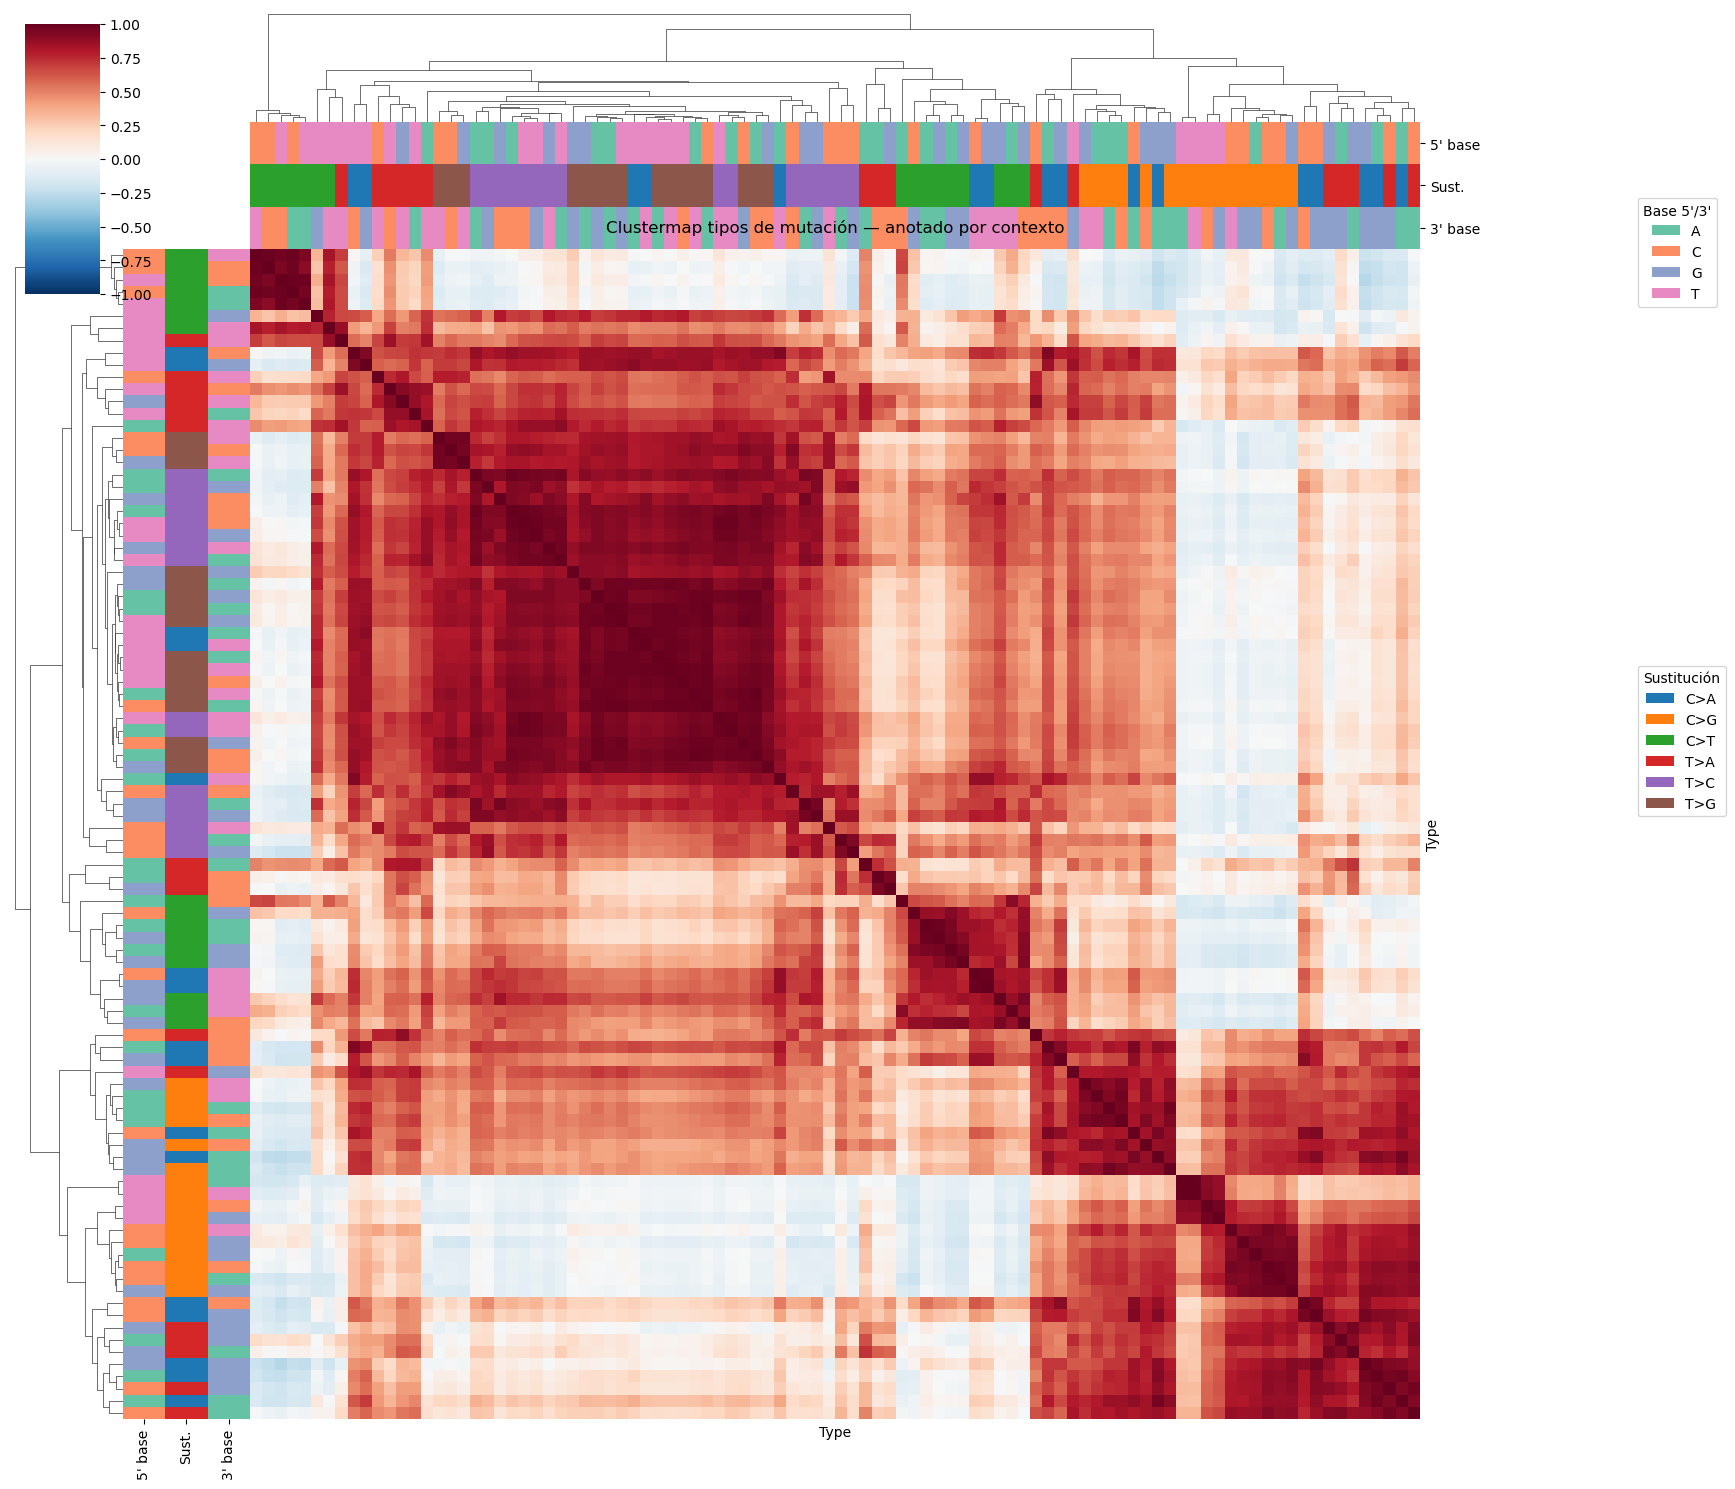

In [46]:
# Extraer las tres componentes de cada contexto (formato "A[C>A]A")
left_base  = [idx[0] for idx in M_df.index]          # letra antes del corchete
sust_type  = [idx.split('[')[1].split(']')[0] for idx in M_df.index]
right_base = [idx[-1] for idx in M_df.index]          # letra después del corchete

# Paletas
bases = ['A', 'C', 'G', 'T']
palette_base = dict(zip(bases, sns.color_palette("Set2", 4)))
palette_sust = dict(zip(['C>A','C>G','C>T','T>A','T>C','T>G'],
                         sns.color_palette("tab10", 6)))

# DataFrame de anotaciones (una columna por característica)
row_colors_df = pd.DataFrame({
    "5' base":    [palette_base[b] for b in left_base],
    "Sust.":      [palette_sust[s] for s in sust_type],
    "3' base":    [palette_base[b] for b in right_base],
}, index=M_df.index)

g = sns.clustermap(
    pd.DataFrame(corr_M_filas, index=M_df.index, columns=M_df.index),
    cmap='RdBu_r', vmin=-1, vmax=1,
    row_colors=row_colors_df,
    col_colors=row_colors_df,
    figsize=(15, 15),
    xticklabels=False, yticklabels=False,
    dendrogram_ratio=0.08,
)
g.ax_heatmap.set_title('Clustermap tipos de mutación — anotado por contexto', pad=12)

# Leyenda bases
from matplotlib.patches import Patch
leg1 = [Patch(facecolor=palette_base[b], label=b) for b in bases]
leg2 = [Patch(facecolor=palette_sust[s], label=s) for s in ['C>A','C>G','C>T','T>A','T>C','T>G']]
l1 = g.ax_heatmap.legend(handles=leg1, title="Base 5'/3'",
                          loc='upper left', bbox_to_anchor=(1.18, 1.05))
g.ax_heatmap.add_artist(l1)
g.ax_heatmap.legend(handles=leg2, title="Sustitución",
                    loc='upper left', bbox_to_anchor=(1.18, 0.65))
plt.show()
plt.close('all')

## Matriz Residuos

In [47]:
S = S_denovo_df.values.astype(float)
A = A_denovo_df.values.T.astype(float)
M_hat = S @ A
U = pd.DataFrame(M - M_hat, index=M_df.index, columns=M_df.columns)
Uv = U.values

### Entre tumores (columnas)

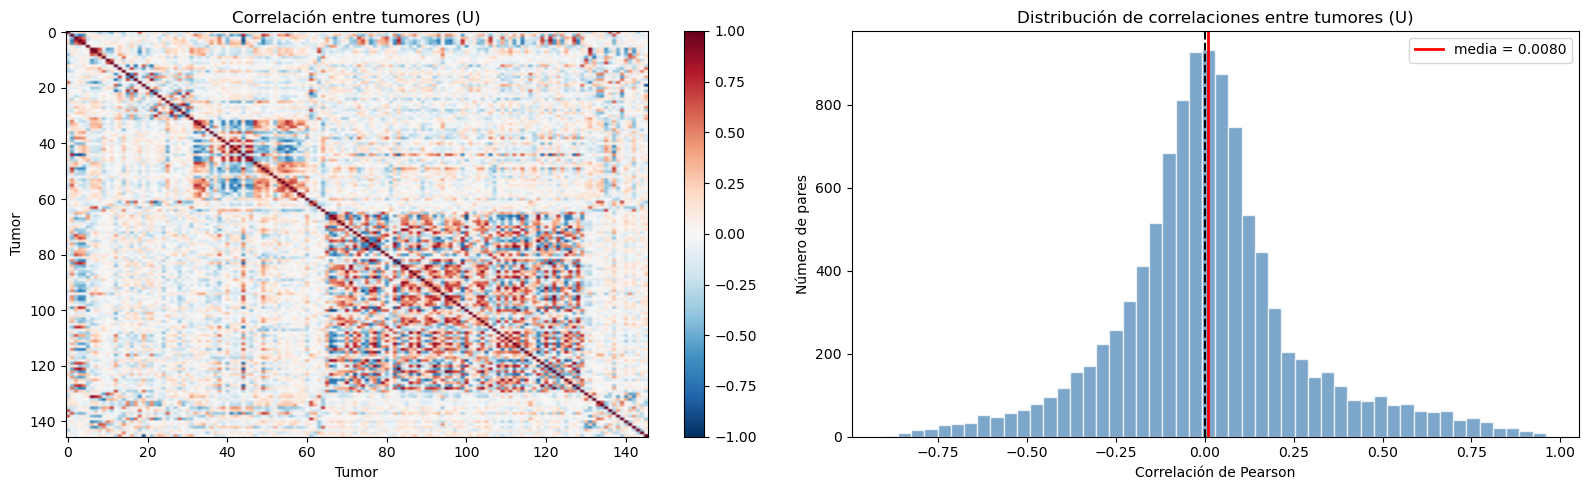

Correlación media: 0.0080
% pares con |corr| > 0.3: 20.7%
% pares con |corr| > 0.5: 8.5%


In [48]:
# Correlación entre tumores (columnas)

corr_U = np.corrcoef(Uv.T)  # (146, 146)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(corr_U, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Correlación entre tumores (U)')
axes[0].set_xlabel('Tumor')
axes[0].set_ylabel('Tumor')
plt.colorbar(im, ax=axes[0])

corr_offdiag_U = corr_U[np.triu_indices(n_tum, k=1)]
axes[1].hist(corr_offdiag_U, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(corr_offdiag_U.mean(), color='red', linewidth=2,
                label=f'media = {corr_offdiag_U.mean():.4f}')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].set_ylabel('Número de pares')
axes[1].set_title('Distribución de correlaciones entre tumores (U)')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close('all')

print(f"Correlación media: {corr_offdiag_U.mean():.4f}")
print(f"% pares con |corr| > 0.3: {(np.abs(corr_offdiag_U) > 0.3).mean()*100:.1f}%")
print(f"% pares con |corr| > 0.5: {(np.abs(corr_offdiag_U) > 0.5).mean()*100:.1f}%")

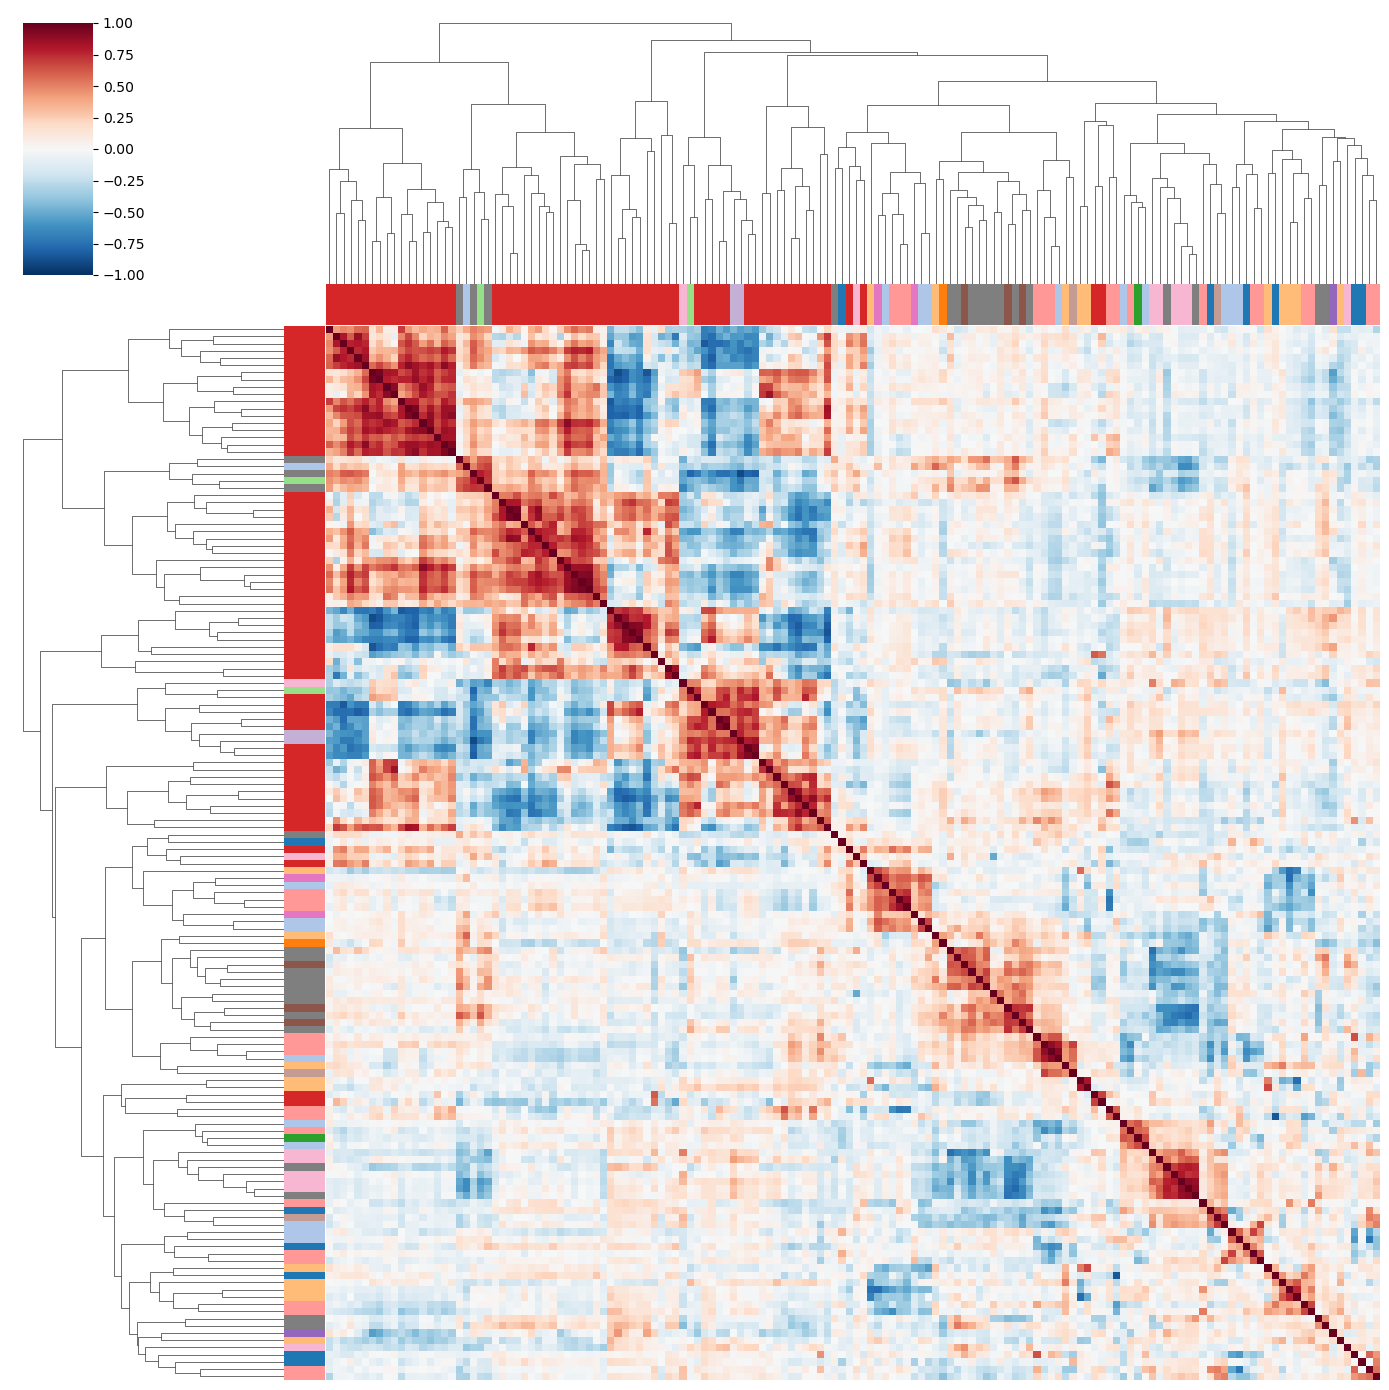

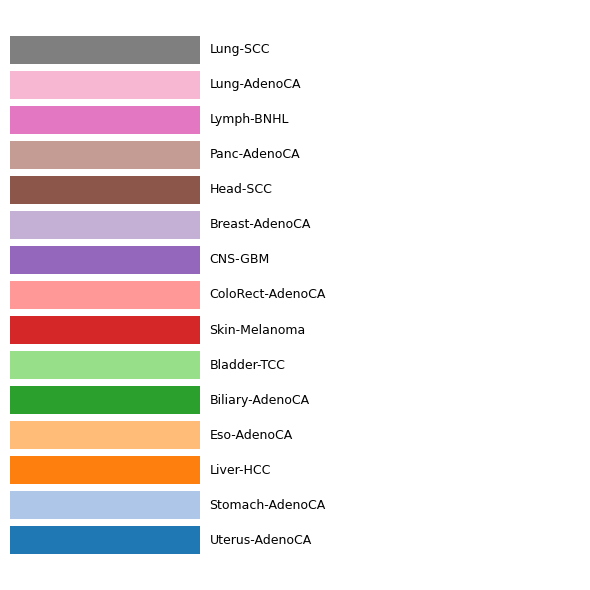

In [49]:
# Clustermap tumores con color por tipo de cáncer
sns.clustermap(pd.DataFrame(corr_U, index=M_df.columns, columns=M_df.columns),
               cmap='RdBu_r', vmin=-1, vmax=1,
               col_colors=col_colors, row_colors=col_colors,
               figsize=(14, 14), xticklabels=False, yticklabels=False)
plt.show()
plt.close('all')

fig, ax = plt.subplots(figsize=(6, len(tipos_unicos) * 0.4))
for i, (tipo, color) in enumerate(color_map.items()):
    ax.barh(i, 1, color=color)
    ax.text(1.05, i, tipo, va='center', fontsize=9)
ax.set_xlim(0, 3)
ax.axis('off')
plt.tight_layout()
plt.show()
plt.close('all')

### Entre tipos de mutación (filas)

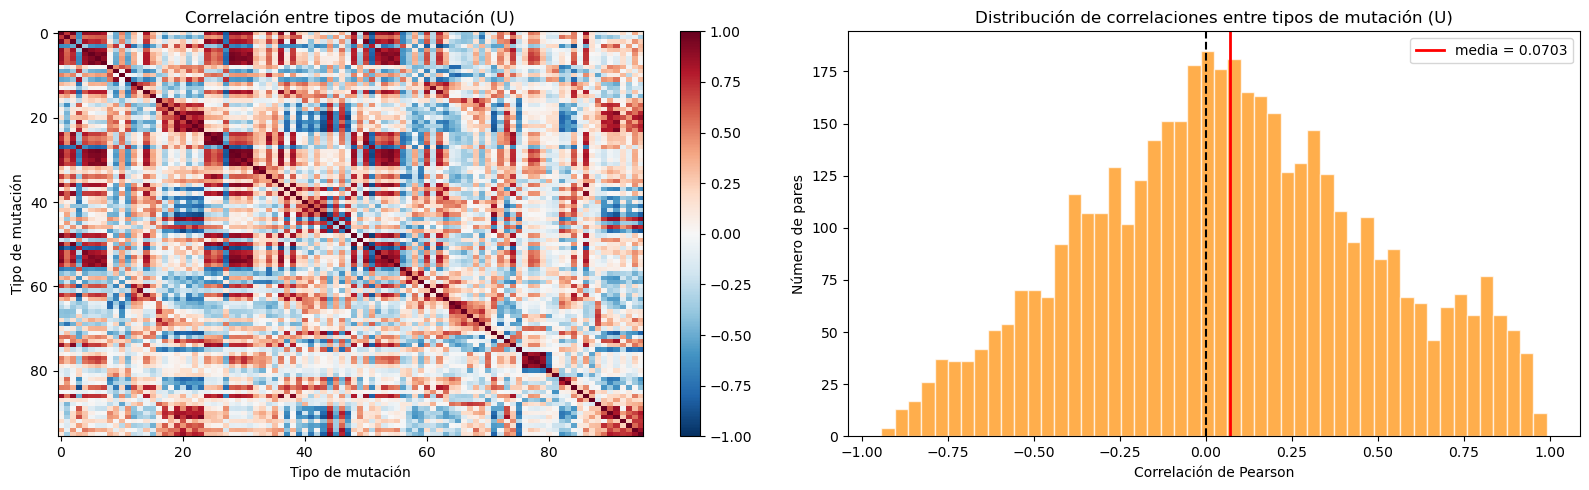

Correlación media: 0.0703
% pares con |corr| > 0.3: 49.1%
% pares con |corr| > 0.5: 25.5%


In [50]:
# Correlación entre tipos de mutación (filas)
corr_U_filas = np.corrcoef(Uv)  # (96, 96)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(corr_U_filas, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Correlación entre tipos de mutación (U)')
axes[0].set_xlabel('Tipo de mutación')
axes[0].set_ylabel('Tipo de mutación')
plt.colorbar(im, ax=axes[0])

corr_offdiag_U_filas = corr_U_filas[np.triu_indices(n_mut, k=1)]
axes[1].hist(corr_offdiag_U_filas, bins=50, color='darkorange', alpha=0.7, edgecolor='white')
axes[1].axvline(corr_offdiag_U_filas.mean(), color='red', linewidth=2,
                label=f'media = {corr_offdiag_U_filas.mean():.4f}')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].set_ylabel('Número de pares')
axes[1].set_title('Distribución de correlaciones entre tipos de mutación (U)')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close('all')

print(f"Correlación media: {corr_offdiag_U_filas.mean():.4f}")
print(f"% pares con |corr| > 0.3: {(np.abs(corr_offdiag_U_filas) > 0.3).mean()*100:.1f}%")
print(f"% pares con |corr| > 0.5: {(np.abs(corr_offdiag_U_filas) > 0.5).mean()*100:.1f}%")

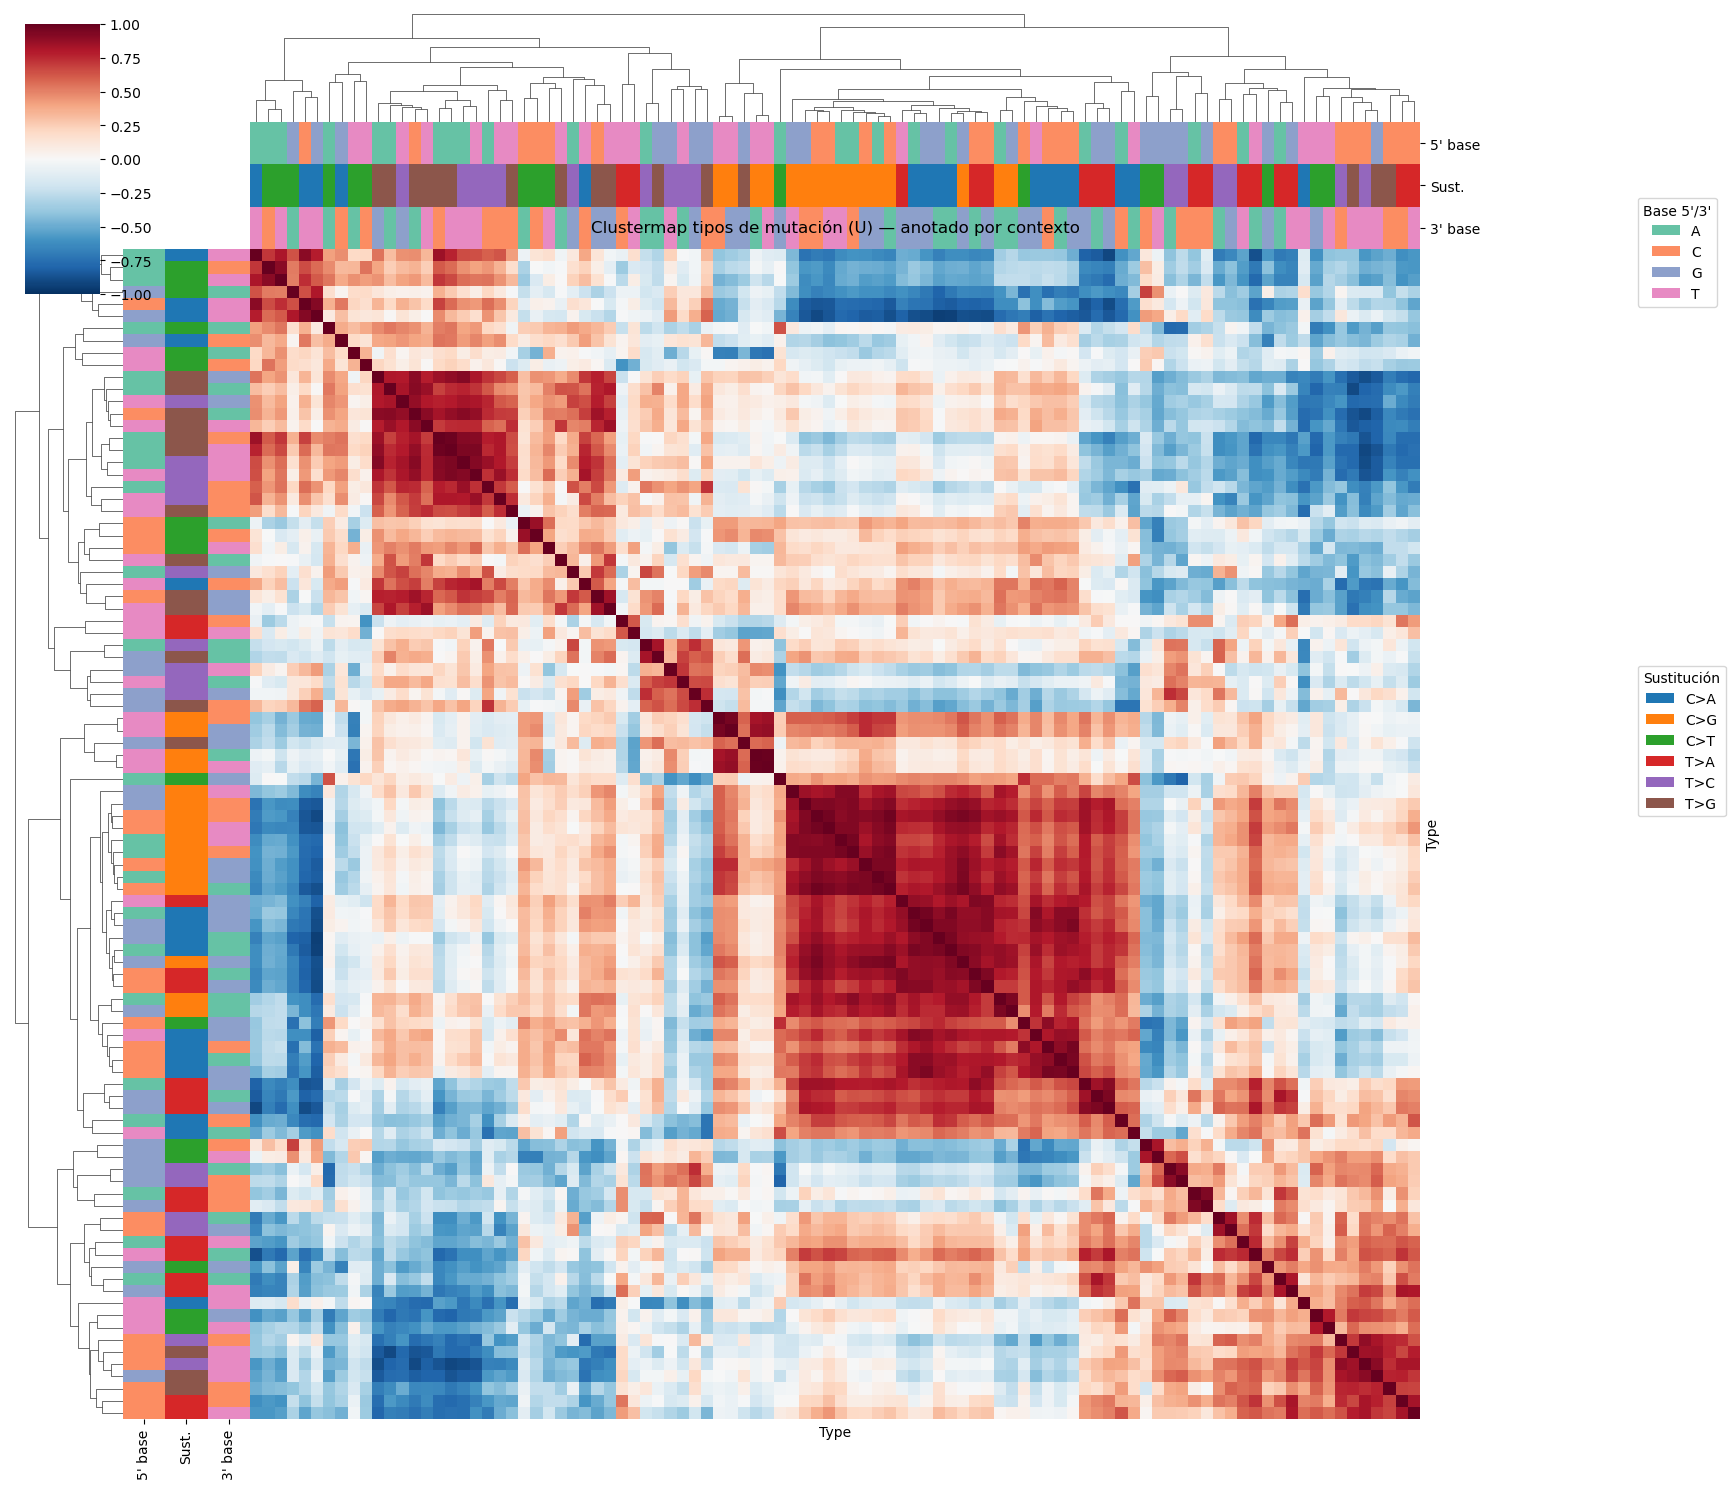

In [51]:
# Clustermap tipos de mutación anotado
g = sns.clustermap(
    pd.DataFrame(corr_U_filas, index=M_df.index, columns=M_df.index),
    cmap='RdBu_r', vmin=-1, vmax=1,
    row_colors=row_colors_df,
    col_colors=row_colors_df,
    figsize=(15, 15),
    xticklabels=False, yticklabels=False,
    dendrogram_ratio=0.08,
)
g.ax_heatmap.set_title('Clustermap tipos de mutación (U) — anotado por contexto', pad=12)
l1 = g.ax_heatmap.legend(handles=leg1, title="Base 5'/3'",
                          loc='upper left', bbox_to_anchor=(1.18, 1.05))
g.ax_heatmap.add_artist(l1)
g.ax_heatmap.legend(handles=leg2, title="Sustitución",
                    loc='upper left', bbox_to_anchor=(1.18, 0.65))
plt.show()
plt.close('all')

# Cálculo de los Residuos

In [52]:
S = S_denovo_df.values.astype(float)      # (96, 8)
A = A_denovo_df.values.T.astype(float)    # (8, 146)

M_hat = S @ A
U = pd.DataFrame(M - M_hat, index=M_df.index, columns=M_df.columns)

print(f"Media residuos (≈ 0): {U.values.mean():.4f}")
print(f"RMSE: {np.sqrt(np.mean(U.values**2)):.4f}")
U

Media residuos (≈ 0): -0.0000
RMSE: 1927.4629


,Biliary-AdenoCA::SP99325,Bladder-TCC::SP1059,Bladder-TCC::SP96136,Breast-AdenoCA::SP117369,Breast-AdenoCA::SP2293,CNS-GBM::SP25494,ColoRect-AdenoCA::SP18310,ColoRect-AdenoCA::SP17172,ColoRect-AdenoCA::SP96133,ColoRect-AdenoCA::SP110242,...,Stomach-AdenoCA::SP84392,Stomach-AdenoCA::SP105018,Stomach-AdenoCA::SP84439,Stomach-AdenoCA::SP84922,Uterus-AdenoCA::SP90209,Uterus-AdenoCA::SP93540,Uterus-AdenoCA::SP93227,Uterus-AdenoCA::SP94933,Uterus-AdenoCA::SP92364,Uterus-AdenoCA::SP92659
Type,,,,,,,,,,,,,,,,,,,,,
A[C>A]A,160.204113,-194.964501,42.441468,38.389734,-2.151904,-162.340823,76.042044,110.131743,82.492678,-467.639394,...,7.986274,-310.146266,-1185.798375,-8.929143,-474.295763,86.367198,-10565.207295,213.425233,138.616416,326.157399
A[C>A]C,166.691375,-114.697880,70.865781,17.053386,-5.622584,-147.184102,-16.574361,-18.564164,-57.201897,-276.067391,...,5.922020,188.831765,-747.920085,21.540497,-379.634220,73.347848,-2266.578502,115.221453,104.692774,228.005614
A[C>A]G,57.134090,-84.593033,12.956147,4.448824,1.578195,-8.276981,11.959701,18.895131,-46.947322,-145.904650,...,-38.103703,-182.124063,-288.606744,10.389294,-37.243199,20.670969,-2207.839453,14.590537,40.839922,78.072010
A[C>A]T,217.983850,-79.209842,6.235441,16.133127,11.114070,-191.980998,-317.269861,-257.535322,-216.120748,-378.992862,...,-161.708552,82.543790,-532.216984,-10.518732,2177.149791,-54.448564,19173.811971,115.032455,204.973153,568.080365
A[C>G]A,-129.218277,5.230083,56.494224,-30.305569,-27.134685,-189.609268,133.499477,98.336974,25.477769,-97.427751,...,-48.388060,219.614435,-786.642745,19.370825,-280.810819,117.619250,-3460.933037,120.814309,-126.088009,22.125944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
T[T>C]T,7.664422,-140.272868,-163.137430,17.627974,4.107813,-359.199708,512.657107,601.564251,145.753621,141.953940,...,142.128066,-48.886776,-338.761127,46.358926,-1441.672757,157.046477,-212.215417,698.483702,-1614.439054,-722.641082
T[T>G]A,478.644071,82.826194,91.676965,-35.105711,-56.619458,-251.569437,-4.019479,40.222553,-8.210260,-97.128399,...,-97.268977,408.995886,-8.873394,-130.057747,-32.909336,-47.251394,-2154.309733,-17.629236,-96.878773,223.038420
T[T>G]C,-80.753624,22.580811,38.756857,-1.301982,-9.302774,-142.862729,5.560645,-9.740637,-30.702729,-22.289755,...,-46.919823,119.612653,-50.379756,-10.304406,224.885838,-29.984146,144.566814,37.067517,-44.212718,-1018.143539


# Análisis de varianza

σ² global:  4310515.29

σ² por columnas (tumores):
  min: 2704.92,  max: 128894822.46,  media: 3754219.52
  Ratio max/min: 47651.9x

σ² por filas (tipos de mutación):
  min: 3792.60,  max: 110113257.33,  media: 3713062.57
  Ratio max/min: 29033.7x


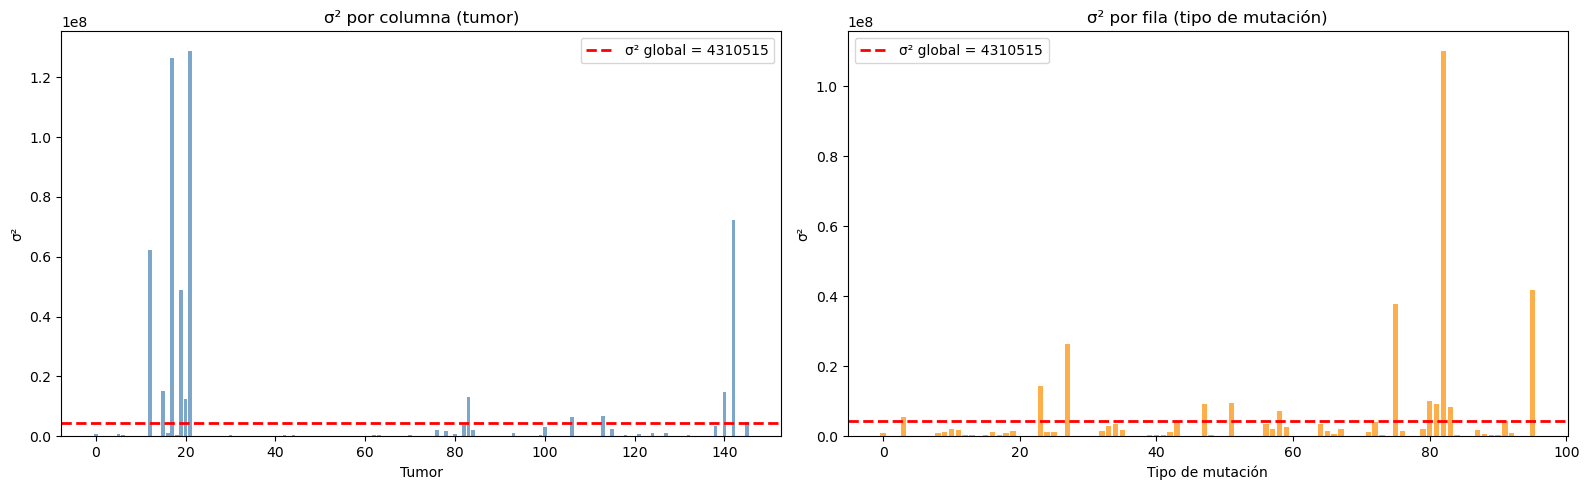

In [53]:
p = S.shape[1] * n_mut + S.shape[1] * n_tum
dof = n_mut * n_tum - p

sigma2_global = np.sum(U.values**2) / dof
sigma2_col = np.var(U.values, axis=0, ddof=1)
sigma2_row = np.var(U.values, axis=1, ddof=1)

print(f"σ² global:  {sigma2_global:.2f}")
print(f"\nσ² por columnas (tumores):")
print(f"  min: {sigma2_col.min():.2f},  max: {sigma2_col.max():.2f},  media: {sigma2_col.mean():.2f}")
print(f"  Ratio max/min: {sigma2_col.max()/sigma2_col.min():.1f}x")
print(f"\nσ² por filas (tipos de mutación):")
print(f"  min: {sigma2_row.min():.2f},  max: {sigma2_row.max():.2f},  media: {sigma2_row.mean():.2f}")
print(f"  Ratio max/min: {sigma2_row.max()/sigma2_row.min():.1f}x")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(n_tum), sigma2_col, color='steelblue', alpha=0.7)
axes[0].axhline(sigma2_global, color='red', linestyle='--', linewidth=2,
                label=f'σ² global = {sigma2_global:.0f}')
axes[0].set_xlabel('Tumor')
axes[0].set_ylabel('σ²')
axes[0].set_title('σ² por columna (tumor)')
axes[0].legend()

axes[1].bar(range(n_mut), sigma2_row, color='darkorange', alpha=0.7)
axes[1].axhline(sigma2_global, color='red', linestyle='--', linewidth=2,
                label=f'σ² global = {sigma2_global:.0f}')
axes[1].set_xlabel('Tipo de mutación')
axes[1].set_ylabel('σ²')
axes[1].set_title('σ² por fila (tipo de mutación)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Variabilidad

In [54]:
Uv = U.values  # numpy array limpio

media_filas = M.mean(axis=1)

VT  = np.sum((M    - media_filas[:, None])**2)
VE  = np.sum((M_hat - media_filas[:, None])**2)
VNE = np.sum((Uv   - Uv.mean(axis=1)[:, None])**2)

print(f"VT  = {VT:.2f}")
print(f"VE  = {VE:.2f}")
print(f"VNE = {VNE:.2f}")
print(f"\n% variabilidad explicada:    {100 * VE / VT:.2f}%")
print(f"% variabilidad no explicada: {100 * VNE / VT:.2f}%")

SS_resid  = np.sum(Uv**2)
SS_total  = np.sum((M - M.mean())**2)
SS_expl   = SS_total - SS_resid

R2 = SS_expl / SS_total

print(f"SS_total  = {SS_total:.2e}")
print(f"SS_expl   = {SS_expl:.2e}")
print(f"SS_resid  = {SS_resid:.2e}")
print(f"\nR² = {R2:.4f}  ({100*R2:.2f}% variabilidad explicada)")
print(f"Residuo relativo (||U||/||M||): {np.linalg.norm(Uv)/np.linalg.norm(M):.4f}")

VT  = 2060107865033.09
VE  = 2124584277623.30
VNE = 51685830994.91

% variabilidad explicada:    103.13%
% variabilidad no explicada: 2.51%
SS_total  = 2.26e+12
SS_expl   = 2.21e+12
SS_resid  = 5.21e+10

R² = 0.9769  (97.69% variabilidad explicada)
Residuo relativo (||U||/||M||): 0.1500


# BOOTSTRAP 

In [55]:
from scipy.optimize import nnls

B = 1000  # número de iteraciones bootstrap
S = S_denovo_df.values.astype(float)  # (96, 8) — fija
n_sig = S.shape[1]

A_boot = np.zeros((B, n_sig, n_tum))  # (1000, 8, 146)

np.random.seed(SEED)

for b in range(B):
    if b % 100 == 0:
        print(f"Bootstrap {b}/{B}...")
    
    # Remuestrear cada tumor por separado
    M_star = np.zeros_like(M)
    for j in range(n_tum):
        counts = M[:, j].astype(int)
        total = counts.sum()
        probs = counts / total
        M_star[:, j] = np.random.multinomial(total, probs)
    
    # Fitting: S fija, encontrar A* con NNLS
    for j in range(n_tum):
        a_star, _ = nnls(S, M_star[:, j])
        A_boot[b, :, j] = a_star

print("Bootstrap completado")

Bootstrap 0/1000...
Bootstrap 100/1000...
Bootstrap 200/1000...
Bootstrap 300/1000...
Bootstrap 400/1000...
Bootstrap 500/1000...
Bootstrap 600/1000...
Bootstrap 700/1000...
Bootstrap 800/1000...
Bootstrap 900/1000...
Bootstrap completado


In [56]:
# Intervalos de confianza al 95%
A_mean  = A_boot.mean(axis=0)                                  # (8, 146)
A_lower = np.percentile(A_boot, 2.5,  axis=0)                 # (8, 146)
A_upper = np.percentile(A_boot, 97.5, axis=0)                 # (8, 146)

print("A_mean shape:", A_mean.shape)
print("IC calculados")

A_mean shape: (8, 146)
IC calculados


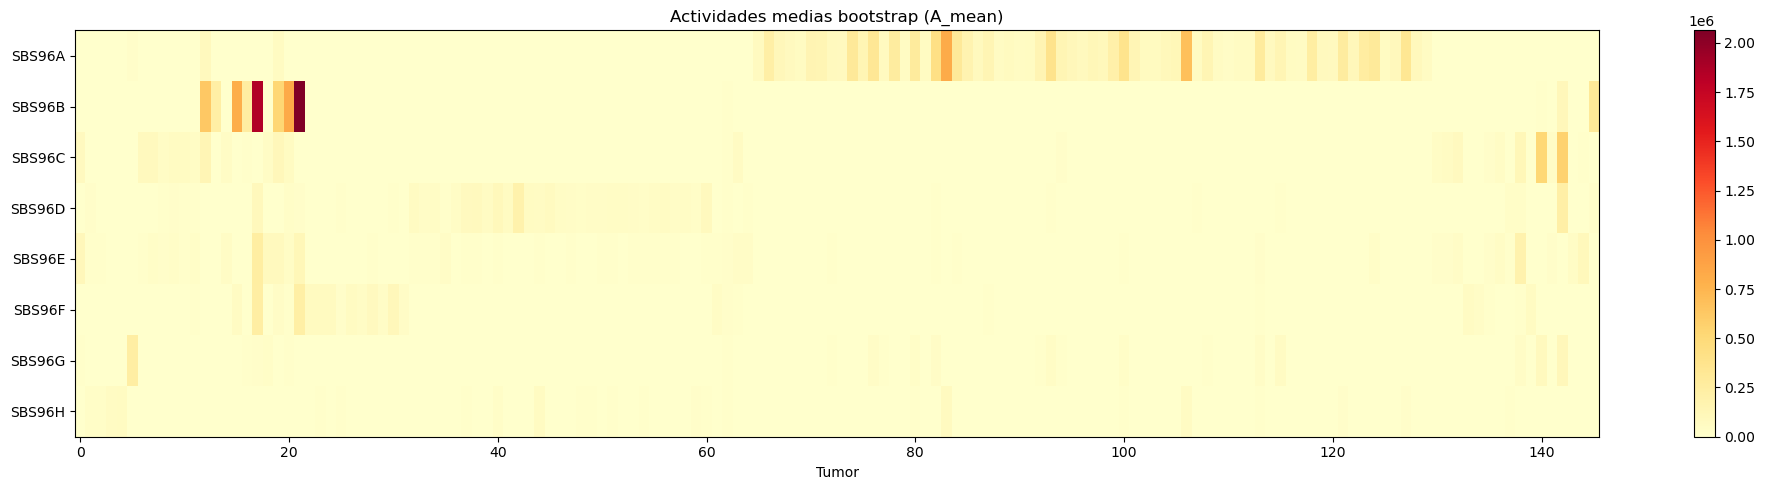

In [57]:
# 1. Heatmap de A_mean — qué firmas dominan en qué tumores
sig_names = S_denovo_df.columns.tolist()
tumor_names = M_df.columns.tolist()

fig, ax = plt.subplots(figsize=(20, 5))
im = ax.imshow(A_mean, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(n_sig))
ax.set_yticklabels(sig_names)
ax.set_xlabel('Tumor')
ax.set_title('Actividades medias bootstrap (A_mean)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
plt.close('all')

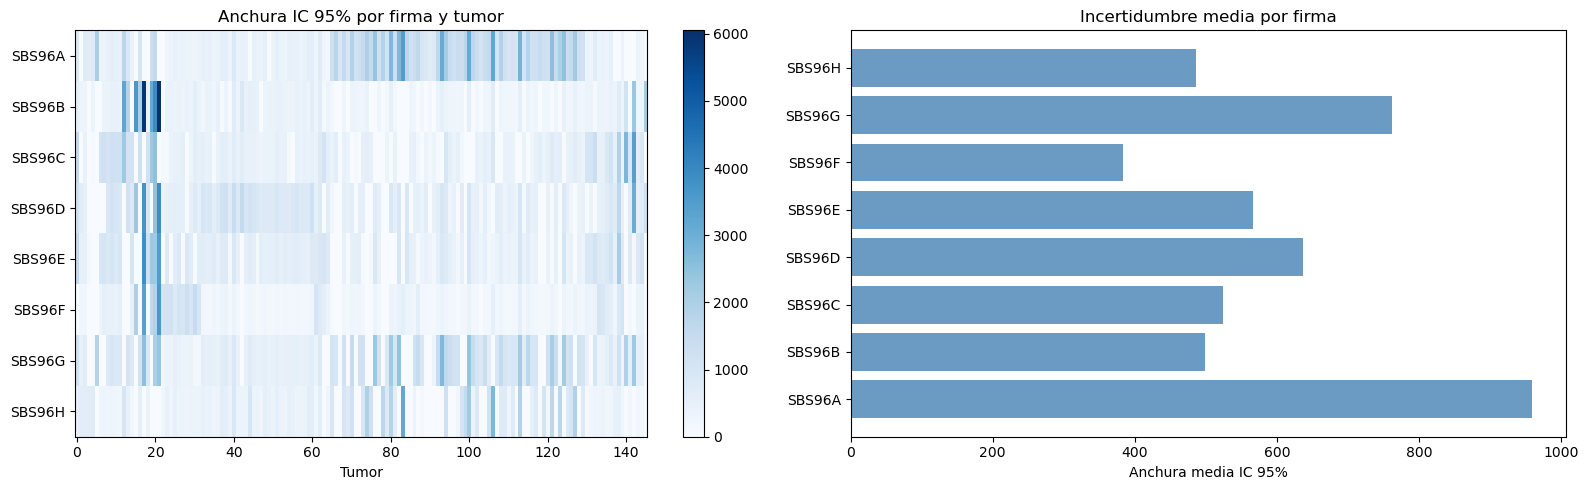

In [58]:
# 2. Anchura del IC — qué tumores/firmas tienen más incertidumbre
IC_width = A_upper - A_lower  # (8, 146)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(IC_width, aspect='auto', cmap='Blues')
axes[0].set_yticks(range(n_sig))
axes[0].set_yticklabels(sig_names)
axes[0].set_xlabel('Tumor')
axes[0].set_title('Anchura IC 95% por firma y tumor')
plt.colorbar(im, ax=axes[0])

# Anchura media por firma
axes[1].barh(sig_names, IC_width.mean(axis=1), color='steelblue', alpha=0.8)
axes[1].set_xlabel('Anchura media IC 95%')
axes[1].set_title('Incertidumbre media por firma')

plt.tight_layout()
plt.show()
plt.close('all')

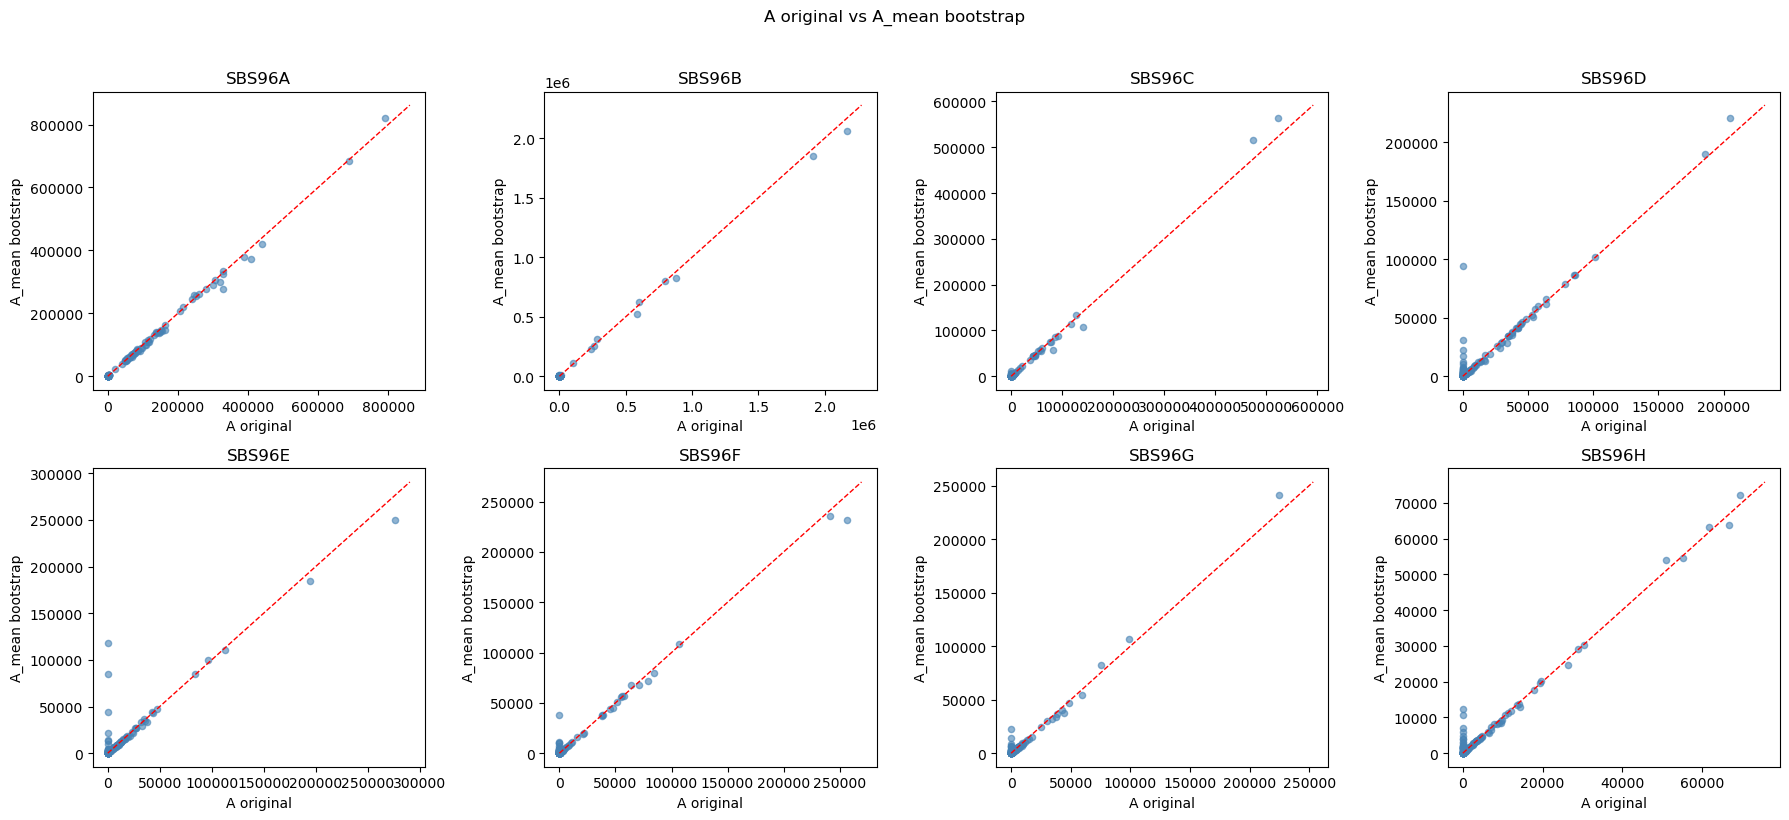

In [59]:
# 3. Comparar A_mean bootstrap vs A original
A_orig = A_denovo_df.values.T.astype(float)  # (8, 146)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, sig in enumerate(sig_names):
    axes[i].scatter(A_orig[i], A_mean[i], alpha=0.6, s=20, color='steelblue')
    lim = max(A_orig[i].max(), A_mean[i].max()) * 1.05
    axes[i].plot([0, lim], [0, lim], 'r--', linewidth=1)
    axes[i].set_title(sig)
    axes[i].set_xlabel('A original')
    axes[i].set_ylabel('A_mean bootstrap')

plt.suptitle('A original vs A_mean bootstrap', y=1.02)
plt.tight_layout()
plt.show()
plt.close('all')

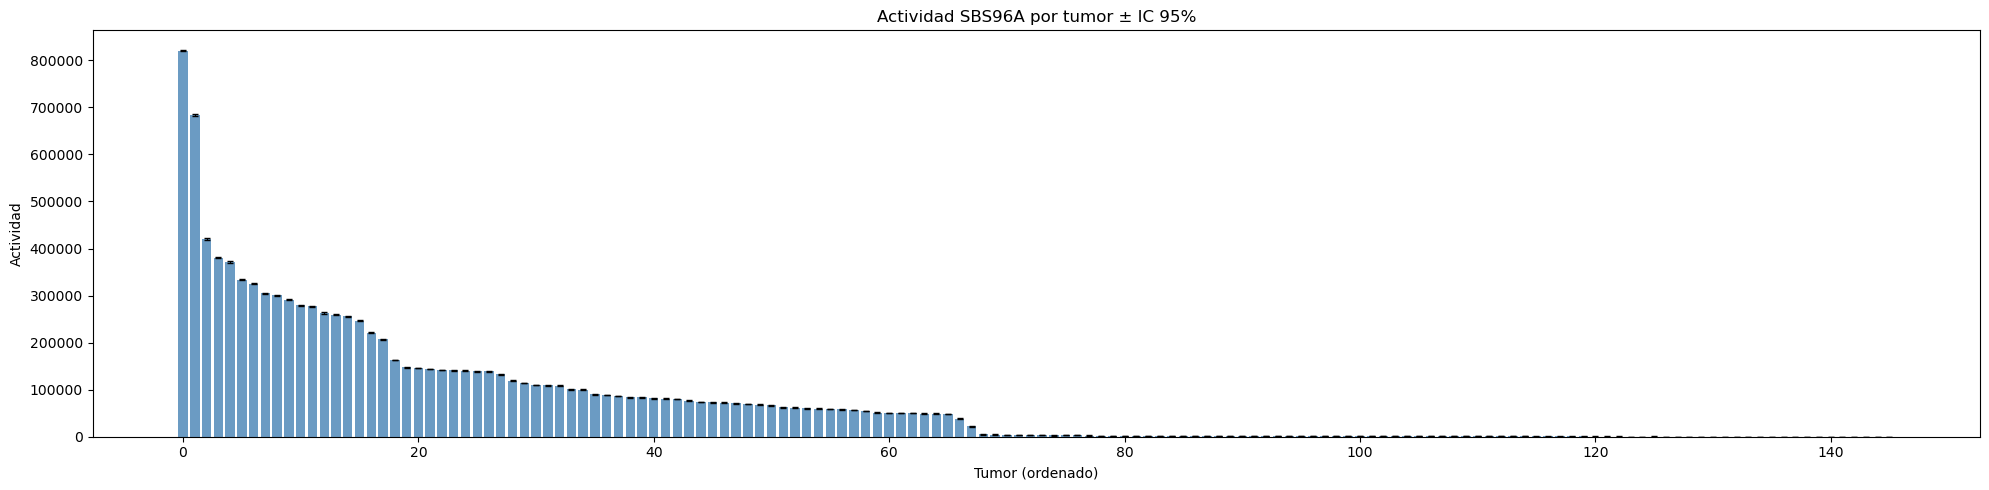

In [60]:
sig_idx = 0

orden = np.argsort(A_mean[sig_idx])[::-1]

err_low  = (A_mean[sig_idx] - A_lower[sig_idx]).clip(0)[orden]
err_high = (A_upper[sig_idx] - A_mean[sig_idx]).clip(0)[orden]

fig, ax = plt.subplots(figsize=(20, 5))
ax.bar(range(n_tum), A_mean[sig_idx][orden], color='steelblue', alpha=0.8)
ax.errorbar(range(n_tum),
            A_mean[sig_idx][orden],
            yerr=[err_low, err_high],
            fmt='none', color='black', capsize=2, linewidth=0.8)
ax.set_xlabel('Tumor (ordenado)')
ax.set_ylabel('Actividad')
ax.set_title(f'Actividad {sig_names[sig_idx]} por tumor ± IC 95%')
plt.tight_layout()
plt.show()
plt.close('all')

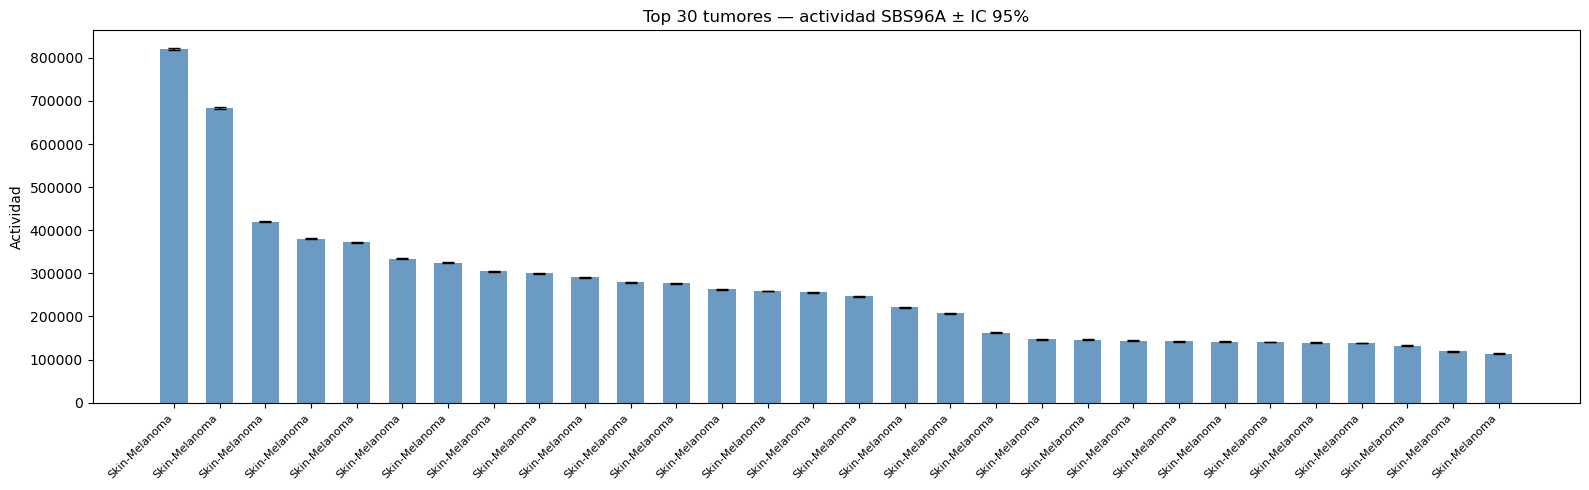

In [61]:
sig_idx = 0
top_n = 30

orden = np.argsort(A_mean[sig_idx])[::-1][:top_n]

err_low  = (A_mean[sig_idx] - A_lower[sig_idx]).clip(0)[orden]
err_high = (A_upper[sig_idx] - A_mean[sig_idx]).clip(0)[orden]
labels   = [M_df.columns[i].split("::")[0] for i in orden]  # solo tipo de cáncer

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(range(top_n), A_mean[sig_idx][orden], color='steelblue', alpha=0.8, width=0.6)
ax.errorbar(range(top_n),
            A_mean[sig_idx][orden],
            yerr=[err_low, err_high],
            fmt='none', color='black', capsize=4, linewidth=1.2)
ax.set_xticks(range(top_n))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Actividad')
ax.set_title(f'Top {top_n} tumores — actividad {sig_names[sig_idx]} ± IC 95%')
plt.tight_layout()
plt.show()
plt.close('all')

In [62]:
cancer_types = [col.split("::")[0] for col in M_df.columns]
from collections import Counter
counts = Counter(cancer_types)
for tipo, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"{tipo}: {n}")

Skin-Melanoma: 65
Lung-SCC: 17
ColoRect-AdenoCA: 16
Eso-AdenoCA: 10
Stomach-AdenoCA: 10
Lung-AdenoCA: 8
Uterus-AdenoCA: 6
Head-SCC: 3
Bladder-TCC: 2
Breast-AdenoCA: 2
Lymph-BNHL: 2
Panc-AdenoCA: 2
Biliary-AdenoCA: 1
CNS-GBM: 1
Liver-HCC: 1
